In [1]:
import tensorflow as tf
print(tf.__version__)


2.13.0


In [2]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Dec 11 00:15:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.09                 Driver Version: 561.09         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080      WDDM  |   00000000:0A:00.0  On |                  N/A |
|  0%   36C    P8             20W /  370W |    2225MiB /  10240MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# !pip install boruta
# !pip install smote_variants
# !pip install lime
# !pip install signaturizer

In [4]:
#import default and other essential libraries
import os
import numpy as np
import pandas as pd
import sklearn
import joblib
import pickle
import csv
import sys
import random
import seaborn as sns
from functools import reduce
import matplotlib.backends.backend_pdf
import matplotlib.pyplot as plt
import tensorflow as tf

In [5]:
#Packages to split data and other preprocessing
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import metrics
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.decomposition import PCA
from boruta import BorutaPy
from imblearn.pipeline import Pipeline as sample_pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

In [6]:
#Import Classifiers
from sklearn import svm
import smote_variants as sv
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

In [7]:
## Package for calculating accuracy and analysis
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score, cohen_kappa_score, f1_score, precision_score, recall_score, matthews_corrcoef
from sklearn.model_selection import StratifiedKFold
from lime.lime_tabular import LimeTabularExplainer

In [8]:
from signaturizer import Signaturizer
from tqdm import tqdm

In [9]:
def handle_missing_values(data):
    print('Handling missing values')
    data = data.replace([np.inf, -np.inf, "", " "], np.nan)
    data = data.replace(["", " "], np.nan)
    for i in data.columns:
        data[i] = data[i].fillna(data[i].mean())
    return data

def Feature_Signaturizer(dat):
    sig_df=pd.DataFrame()
    desc=['A','B','C','D','E']
    for dsc in tqdm(desc):
        for i in range(1,6):
            sign = Signaturizer(dsc+str(i), local=True)
            results = sign.predict(dat)
            df=pd.DataFrame(results.signature)
            for clm in list(df.columns):
                df=df.rename(columns={clm:dsc+str(i)+'_'+str(clm)})
            sig_df=pd.concat([sig_df,df],axis = 1)
    sig_df = handle_missing_values(sig_df)
    res = pd.DataFrame()
    res['smiles'] = dat
    res = pd.concat([res,sig_df],axis = 1)
    return res

In [10]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/Zz/Desktop/致癌性课题/00. 机器学习相关内容/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'AID_1199_datatable_all.csv') ### features in columns,molecules in rows
# 1. 根据列名为 PUBCHEM_CID 的取值去除重复的
data = data.drop_duplicates(subset='PUBCHEM_CID')

# 2. 替换 PUBCHEM_ACTIVITY_OUTCOME 列的取值
data['PUBCHEM_ACTIVITY_OUTCOME'] = data['PUBCHEM_ACTIVITY_OUTCOME'].replace({
    'Active': 1,
    'Inactive': 0,
    'Unspecified': np.nan
})

# 将 'Status' 列名修改为 'status'
data = data.rename(columns={'PUBCHEM_ACTIVITY_OUTCOME': 'status'})

# 3. 删除 SMILES 和 PUBCHEM_ACTIVITY_OUTCOME 两列中任一有空值的行
data = data.dropna(subset=['SMILES', 'status'])

# 4. 重新设置索引
data.reset_index(drop=True, inplace=True)

# 输出处理后的数据
data

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,SMILES,status
0,6,48414509,5284462.0,COP(=O)(OC)O/C(=C\Cl)/C1=CC(=C(C=C1Cl)Cl)Cl,1.0
1,7,48413127,62805.0,C1=CC=C2C(=C1)C3=C(N2)N=C(C=C3)N,1.0
2,8,48413128,11074431.0,CC1=CC(=O)[N-]S(=O)(=O)O1.[K+],0.0
3,9,48413130,9548611.0,C/C=N/N(C)C=O,1.0
4,10,48413132,178.0,CC(=O)N,1.0
...,...,...,...,...,...
956,1002,48414653,5281576.0,C[C@H]1CCCC(=O)CCC/C=C/C2=C(C(=CC(=C2)O)O)C(=O)O1,1.0
957,1003,48414655,5284483.0,CCCCN(CCCC)C(=S)[S-].CCCCN(CCCC)C(=S)[S-].[Zn+2],0.0
958,1004,48414656,26633.0,CCN(CC)C(=S)[S-].CCN(CC)C(=S)[S-].[Zn+2],0.0
959,1005,48414657,8722.0,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Zn+2],0.0


In [11]:
# 提取 SMILES 列
data_smiles = data['SMILES']
# 使用 Feature_Signaturizer 计算特征
data_features = Feature_Signaturizer(data_smiles)

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]
Parsing SMILES: 0it [00:00, ?it/s]
Parsing SMILES: 961it [00:00, 8142.32it/s]

Generating signatures:   0%|                                                                     | 0/8 [00:00<?, ?it/s]

1/1 [==============================] - 0s 49ms/step



Generating signatures:  12%|███████▋                                                     | 1/8 [00:00<00:02,  2.58it/s]

1/1 [==============================] - 0s 20ms/step



Generating signatures:  25%|███████████████▎                                             | 2/8 [00:00<00:01,  3.19it/s]

...

1/1 [==============================] - 0s 20ms/step



Generating signatures:  88%|█████████████████████████████████████████████████████▍       | 7/8 [00:01<00:00,  3.77it/s]

1/1 [==============================] - 0s 45ms/step



100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:24<00:00, 16.95s/it]

Handling missing values


In [12]:
# 保留原始的 'status' 列
data = pd.concat([data_features, data['status']], axis=1)
data.to_csv('data_1199.csv')
# 打印查看结果
print(data)

                                                smiles      A1_0      A1_1  \
0          COP(=O)(OC)O/C(=C\Cl)/C1=CC(=C(C=C1Cl)Cl)Cl -0.104004  0.097742   
1                     C1=CC=C2C(=C1)C3=C(N2)N=C(C=C3)N  0.093736  0.085740   
2                       CC1=CC(=O)[N-]S(=O)(=O)O1.[K+] -0.100093 -0.099089   
3                                        C/C=N/N(C)C=O -0.098334 -0.081190   
4                                              CC(=O)N -0.096465  0.053733   
..                                                 ...       ...       ...   
956  C[C@H]1CCCC(=O)CCC/C=C/C2=C(C(=CC(=C2)O)O)C(=O)O1  0.086596  0.097404   
957   CCCCN(CCCC)C(=S)[S-].CCCCN(CCCC)C(=S)[S-].[Zn+2] -0.084912  0.094649   
958           CCN(CC)C(=S)[S-].CCN(CC)C(=S)[S-].[Zn+2] -0.096963  0.096943   
959               CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Zn+2] -0.097245  0.073241   
960         [O-]S(=O)(=O)[O-].[O-]S(=O)(=O)[O-].[Zr+4] -0.036443  0.094002   

         A1_2      A1_3      A1_4      A1_5      A1_6      A1_7

In [15]:
# dropping ALL duplicate values, if any
data.drop_duplicates(subset ="smiles", keep = 'first', inplace = True, ignore_index = True)
data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,COP(=O)(OC)O/C(=C\Cl)/C1=CC(=C(C=C1Cl)Cl)Cl,-0.103999,0.097738,0.100539,-0.103800,0.061276,-0.105713,-0.006544,0.027760,-0.060200,...,-0.001032,-0.138497,0.067248,0.075819,-0.061462,0.121833,0.110668,0.057597,0.113798,1.0
1,C1=CC=C2C(=C1)C3=C(N2)N=C(C=C3)N,0.093736,0.085746,0.093669,-0.093733,-0.093736,-0.093322,0.093736,-0.093720,-0.093735,...,0.119321,-0.005243,-0.015744,-0.010452,0.022232,0.016749,0.094246,-0.123218,-0.099457,1.0
2,CC1=CC(=O)[N-]S(=O)(=O)O1.[K+],-0.100092,-0.099088,-0.084504,-0.094028,0.085655,0.100332,0.010789,-0.028890,0.082395,...,-0.014538,-0.108730,0.071725,0.064377,-0.096417,-0.119392,0.056950,0.105985,0.040311,0.0
3,C/C=N/N(C)C=O,-0.098335,-0.081193,0.049595,-0.061777,-0.066672,-0.022043,0.087456,-0.098040,0.047128,...,-0.059380,-0.026610,0.045300,-0.068234,0.028847,-0.068210,0.011231,0.146784,-0.091332,1.0
4,CC(=O)N,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,...,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,C[C@H]1CCCC(=O)CCC/C=C/C2=C(C(=CC(=C2)O)O)C(=O)O1,0.086594,0.097406,0.096966,-0.097145,0.097028,-0.091569,-0.071954,0.097492,0.096533,...,-0.141212,-0.046718,-0.069887,0.049093,-0.093039,-0.117753,0.079444,0.002861,0.134517,1.0
957,CCCCN(CCCC)C(=S)[S-].CCCCN(CCCC)C(=S)[S-].[Zn+2],-0.084900,0.094649,0.092521,0.063585,-0.094093,0.094662,0.094667,-0.094671,-0.056504,...,-0.035826,-0.032917,-0.005921,0.106586,-0.022346,-0.005595,0.090953,0.174594,0.115123,0.0
958,CCN(CC)C(=S)[S-].CCN(CC)C(=S)[S-].[Zn+2],-0.096963,0.096944,0.055419,0.031063,-0.096089,0.097074,0.097105,-0.097106,-0.046417,...,-0.033102,0.000861,-0.028923,0.096171,0.038505,-0.103363,0.118180,0.117282,0.098737,0.0
959,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Zn+2],-0.097246,0.073239,0.031616,0.070694,-0.013785,0.097282,0.097095,-0.097314,-0.061902,...,-0.037974,-0.103768,0.069785,0.098978,-0.064144,-0.107851,0.066537,0.132164,0.064070,0.0


In [16]:
def Boruta_Filteration(X_train,y_train,X_test,y_test):
    #### making files for boruta
    features = [f for f in X_train.columns if f not in ['status']]
    X_train_boruta = X_train[features].values
    Y_train_boruta = y_train.values.ravel()
    X_test_boruta = X_test[features].values
    Y_test_boruta = y_test.values.ravel()

    print('Before filteration\nTrain shape\n',X_train_boruta.shape,'\nTest shape\n',X_test_boruta.shape)

    ### implementing boruta

    # define random forest classifier, with utilising all cores and
    # sampling in proportion to y labels
    rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

    # define Boruta feature selection method
    feat_selector = BorutaPy(rf, n_estimators=100, random_state=1)

    # find all relevant features - 5 features should be selected
    feat_selector.fit(X_train_boruta, Y_train_boruta)

    # check selected features - first 5 features are selected
    feat_selector.support_

    # check ranking of features
    feat_selector.ranking_

    # call transform() on X to filter it down to selected features
    X_train_filtered = feat_selector.transform(X_train_boruta)
    X_test_filtered = feat_selector.transform(X_test_boruta)

    ### name of the features selected####
    final_features = list()
    indexes = np.where(feat_selector.support_ == True)
    for x in np.nditer(indexes):
        final_features.append(features[x])

    print('# of Features selected:',len(final_features))

    X_train_filtered=pd.DataFrame(X_train_filtered,columns=final_features)
    X_test_filtered=pd.DataFrame(X_test_filtered,columns=final_features)

    print('After filteration\nTrain shape\n',X_train_filtered.shape,'\nTest shape\n',X_test_filtered.shape)

    return X_train_filtered,X_test_filtered,Y_train_boruta,Y_test_boruta,final_features

In [17]:
'''
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        #plt.legend(loc="lower right")
        plt.show()
'''

'\ndef TSNE_plot(data,data_labels):\n        tsne = TSNE(n_components=2, random_state=50)\n        transformed_data = tsne.fit_transform(data)\n        k = np.array(transformed_data)\n        Group=["Class 0","Class 1"]\n        plt.scatter(k[:, 0],k[:, 1], c=data_labels)\n        #plt.legend(loc="lower right")\n        plt.show()\n'

In [18]:
def Smote(traindata,trainlabel,prop):
        oversampler= sv.MSMOTE(proportion=prop,random_state=50)
        X_samp, y_samp= oversampler.sample(traindata.values,trainlabel.values)     
        TSNE_plot(X_samp, y_samp)
        X_samp= pd.DataFrame(X_samp)
        y_samp=pd.DataFrame(y_samp)
        X_samp.columns =list(traindata.columns.values)
        return X_samp,y_samp
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        plt.legend(loc="lower right")
        plt.show()

In [19]:
# Set random seed to maintain the randomness of each hyperparameter tuning run
def seed_all():
    np.random.seed(123)
    tf.random.set_seed(123)
seed_all()

In [20]:
# Make a new directory for HyperParameter Tuning
os.mkdir('AID_1199')

In [21]:
# FROM = Path of directory from which to load the preprocessed signaturizer file
FROM='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao'
# TO = Path of the newly made HyperParameter Tuning directory
TO='C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao/AID_1199/'

# Set the HPTuning directory as the current working directory
os.chdir(TO)

In [22]:
Data=data.dropna()
Data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,COP(=O)(OC)O/C(=C\Cl)/C1=CC(=C(C=C1Cl)Cl)Cl,-0.103999,0.097738,0.100539,-0.103800,0.061276,-0.105713,-0.006544,0.027760,-0.060200,...,-0.001032,-0.138497,0.067248,0.075819,-0.061462,0.121833,0.110668,0.057597,0.113798,1.0
1,C1=CC=C2C(=C1)C3=C(N2)N=C(C=C3)N,0.093736,0.085746,0.093669,-0.093733,-0.093736,-0.093322,0.093736,-0.093720,-0.093735,...,0.119321,-0.005243,-0.015744,-0.010452,0.022232,0.016749,0.094246,-0.123218,-0.099457,1.0
2,CC1=CC(=O)[N-]S(=O)(=O)O1.[K+],-0.100092,-0.099088,-0.084504,-0.094028,0.085655,0.100332,0.010789,-0.028890,0.082395,...,-0.014538,-0.108730,0.071725,0.064377,-0.096417,-0.119392,0.056950,0.105985,0.040311,0.0
3,C/C=N/N(C)C=O,-0.098335,-0.081193,0.049595,-0.061777,-0.066672,-0.022043,0.087456,-0.098040,0.047128,...,-0.059380,-0.026610,0.045300,-0.068234,0.028847,-0.068210,0.011231,0.146784,-0.091332,1.0
4,CC(=O)N,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,...,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,C[C@H]1CCCC(=O)CCC/C=C/C2=C(C(=CC(=C2)O)O)C(=O)O1,0.086594,0.097406,0.096966,-0.097145,0.097028,-0.091569,-0.071954,0.097492,0.096533,...,-0.141212,-0.046718,-0.069887,0.049093,-0.093039,-0.117753,0.079444,0.002861,0.134517,1.0
957,CCCCN(CCCC)C(=S)[S-].CCCCN(CCCC)C(=S)[S-].[Zn+2],-0.084900,0.094649,0.092521,0.063585,-0.094093,0.094662,0.094667,-0.094671,-0.056504,...,-0.035826,-0.032917,-0.005921,0.106586,-0.022346,-0.005595,0.090953,0.174594,0.115123,0.0
958,CCN(CC)C(=S)[S-].CCN(CC)C(=S)[S-].[Zn+2],-0.096963,0.096944,0.055419,0.031063,-0.096089,0.097074,0.097105,-0.097106,-0.046417,...,-0.033102,0.000861,-0.028923,0.096171,0.038505,-0.103363,0.118180,0.117282,0.098737,0.0
959,CN(C)C(=S)[S-].CN(C)C(=S)[S-].[Zn+2],-0.097246,0.073239,0.031616,0.070694,-0.013785,0.097282,0.097095,-0.097314,-0.061902,...,-0.037974,-0.103768,0.069785,0.098978,-0.064144,-0.107851,0.066537,0.132164,0.064070,0.0


In [23]:
# Use 90% of the Data as Training Data for further hyperparameter tuning
Train=Data.sample(n=int(len(Data)*0.9), random_state=1)
Train

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
241,C1=CC2=C(C(=C1)O)N=CC=C2.C1=CC2=C(C(=C1)O)N=CC...,0.052346,-0.099031,-0.088357,-0.095915,-0.098000,-0.064114,0.093757,-0.075372,-0.097093,...,0.084163,-0.138303,-0.032410,-0.025601,0.024313,0.159301,0.127973,0.033809,-0.072447,0.0
852,C(C(Cl)Cl)(Cl)Cl,-0.095172,0.076068,-0.095016,0.092078,-0.076338,0.095233,0.095232,-0.095222,-0.063478,...,-0.021423,-0.083602,-0.024831,0.070732,0.072890,0.035392,0.072487,0.172468,0.055442,1.0
436,[F-].[Na+],-0.095215,0.060828,-0.085709,-0.072397,-0.094919,0.094752,0.095217,-0.094895,-0.075561,...,0.066997,-0.058300,-0.028299,0.111511,-0.082632,-0.085210,0.139600,0.031157,0.104471,0.0
386,C1C2C(COS(=O)O1)C3(C(=C(C2(C3(Cl)Cl)Cl)Cl)Cl)Cl,-0.107308,0.098852,0.102588,-0.107210,0.088127,-0.095301,0.022453,0.106743,-0.065079,...,-0.026380,-0.074429,0.136978,0.029086,-0.011654,-0.075298,-0.067889,0.042159,-0.048472,0.0
345,COP(=O)(C)OC,-0.090855,0.097003,0.096876,0.064873,0.086843,0.095678,0.096737,-0.097032,-0.096912,...,-0.024818,-0.055168,-0.102020,0.019177,-0.087249,0.033317,0.150255,0.143216,0.102201,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793,CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/C(=O)O)/C)/C,-0.059514,0.095309,0.095309,-0.095305,0.095134,-0.095308,0.086687,0.095303,0.094705,...,-0.124965,-0.040129,-0.080237,0.119994,0.091310,-0.006321,-0.105766,0.113220,-0.045263,0.0
87,C1=CC=C(C=C1)C(=O)[O-].[Na+],-0.099007,0.079812,-0.085235,0.085768,-0.031986,0.099143,0.098854,-0.099138,-0.063453,...,0.040862,-0.098792,0.078318,0.104237,-0.106265,-0.115352,0.116511,-0.078842,0.102723,0.0
751,C=CC1=CC=CC=[N+]1[O-],-0.094778,-0.100613,0.100790,-0.093948,0.100723,-0.031504,-0.089807,-0.095741,0.074465,...,-0.079320,-0.076754,-0.030149,-0.120517,-0.029786,-0.105358,-0.037950,0.066158,-0.112120,0.0
655,C1=CC(=C(C=C1[N+](=O)[O-])N)C(=O)O,-0.091352,-0.091352,0.091352,0.040123,0.091352,0.091349,-0.091352,-0.091352,-0.090892,...,0.040000,-0.059648,0.076668,-0.021628,-0.050511,0.046782,-0.049856,0.062454,0.027315,0.0


In [24]:
def HPTing_Model(Train_x, Train_y):
    n_estimators = [int(x) for x in np.linspace(start = 2, stop = 100, num = 10)]
    max_features = ['sqrt', 'log2', None, 0.5]
    max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
    max_depth.append(None)
    min_samples_split = list(range(2,30))
    min_samples_leaf = list(range(1,20))
    bootstrap = [True, False]
    random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
    rf = RandomForestClassifier()
    rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 5, verbose=2, n_jobs = -1)
    rf_random.fit(Train_x, Train_y)
    return rf_random

In [25]:
def get_labels(pred_test,thsd): #Getting discrete labels from probability values    
    test_label = [] 
    for i in range(len(pred_test)):
        if pred_test[i]>thsd:
            test_label.append(1)
        else:
            test_label.append(0)
    return test_label

In [26]:
'''
def Scoring_metrices(label, pred, truth, D):
    score={}
    
    accuracy = metrics.accuracy_score(truth, label)
    score[D+" Accuracy:"] = accuracy
    print(D+" Accuracy:", accuracy)
    
    mcc_score = matthews_corrcoef(truth, label)
    score[D+" MCC Score:"] = mcc_score
    print(D+" MCC Score:",mcc_score)
    
    F1_score = f1_score(truth, label, average='macro')
    score[D+" F1 Score:"] = F1_score
    print(D+" F1 Score:", F1_score)
    
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D+" AUC VALUE:"] = roc_auc
    print(D+" AUC VALUE:",roc_auc)
    
    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)
    score[D+" kappa Score:"] = kappa_rf
    print(D+" kappa Score:",kappa_rf)
    
    Precision_score = metrics.precision_score(truth, label)
    score[D+" Precision:"] = Precision_score
    print(D+" Precision:", Precision_score)
    
    Recall_score = metrics.recall_score(truth, label)
    score[D+" Recall:"] = Recall_score
    print(D+" Recall:", Recall_score)
    
    
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    return score
'''

'\ndef Scoring_metrices(label, pred, truth, D):\n    score={}\n    \n    accuracy = metrics.accuracy_score(truth, label)\n    score[D+" Accuracy:"] = accuracy\n    print(D+" Accuracy:", accuracy)\n    \n    mcc_score = matthews_corrcoef(truth, label)\n    score[D+" MCC Score:"] = mcc_score\n    print(D+" MCC Score:",mcc_score)\n    \n    F1_score = f1_score(truth, label, average=\'macro\')\n    score[D+" F1 Score:"] = F1_score\n    print(D+" F1 Score:", F1_score)\n    \n    fpr, tpr, _ = roc_curve(truth, pred)\n    roc_auc = auc(fpr, tpr)\n    score[D+" AUC VALUE:"] = roc_auc\n    print(D+" AUC VALUE:",roc_auc)\n    \n    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)\n    score[D+" kappa Score:"] = kappa_rf\n    print(D+" kappa Score:",kappa_rf)\n    \n    Precision_score = metrics.precision_score(truth, label)\n    score[D+" Precision:"] = Precision_score\n    print(D+" Precision:", Precision_score)\n    \n    Recall_score = metrics.recall_score(truth, label)\n    score[D+"

In [27]:
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, f1_score, roc_curve, auc

def Scoring_metrices(label, pred, truth, D):
    score = {}
    
    # 计算准确率
    accuracy = metrics.accuracy_score(truth, label)
    score[D + " Accuracy:"] = accuracy
    print(D + " Accuracy:", accuracy)
    
    # 计算Matthews相关系数
    mcc_score = matthews_corrcoef(truth, label)
    score[D + " MCC Score:"] = mcc_score
    print(D + " MCC Score:", mcc_score)
    
    # 计算F1分数
    F1_score = f1_score(truth, label, average='macro')
    score[D + " F1 Score:"] = F1_score
    print(D + " F1 Score:", F1_score)
    
    # 计算ROC曲线和AUC
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D + " AUC VALUE:"] = roc_auc
    print(D + " AUC VALUE:", roc_auc)
    
    # 计算Kappa值
    kappa_rf = metrics.cohen_kappa_score(truth, label)
    score[D + " kappa Score:"] = kappa_rf
    print(D + " kappa Score:", kappa_rf)
    
    # 计算精准率
    Precision_score = metrics.precision_score(truth, label)
    score[D + " Precision:"] = Precision_score
    print(D + " Precision:", Precision_score)
    
    # 计算召回率
    Recall_score = metrics.recall_score(truth, label)
    score[D + " Recall:"] = Recall_score
    print(D + " Recall:", Recall_score)
    
    # 计算灵敏度、特异性、总体正确率和阳性预测值
    TP = ((truth == 1) & (label == 1)).sum()
    TN = ((truth == 0) & (label == 0)).sum()
    FP = ((truth == 0) & (label == 1)).sum()
    FN = ((truth == 1) & (label == 0)).sum()

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    CCR = (TP + TN) / len(truth) if len(truth) > 0 else 0
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0

    # 打印敏感性、特异性、CCR和PPV
    score[D + " Sensitivity:"] = sensitivity
    print(D + " Sensitivity:", sensitivity)
    
    score[D + " Specificity:"] = specificity
    print(D + " Specificity:", specificity)
    
    score[D + " CCR:"] = CCR
    print(D + " CCR:", CCR)
    
    score[D + " PPV:"] = PPV
    print(D + " PPV:", PPV)

    # 绘制ROC曲线
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    
    return score


Fold # 0 Random Seed: 589
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:15:45,402:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:15:45,404:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:15:45,404:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 32
After filteration
Train shape
 (691, 32) 
Test shape
 (173, 32)
Before Oversampling
y_train_filtered
 0.0    375
1.0    316
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


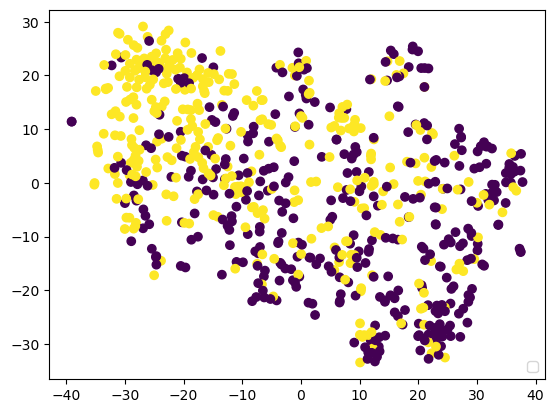

After Oversampling
Final_Ytrain
 0  
0.0    375
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9736111111111111
Training MCC Score: 0.947127971888543
Training F1 Score: 0.9735621010399294
Training AUC VALUE: 0.9970705314009662
Training kappa Score: 0.9471243042671614
Training Precision: 0.9738372093023255
Training Recall: 0.9710144927536232
Training Sensitivity: 0.9710144927536232
Training Specificity: 0.976
Training CCR: 0.9736111111111111
Training PPV: 0.9738372093023255


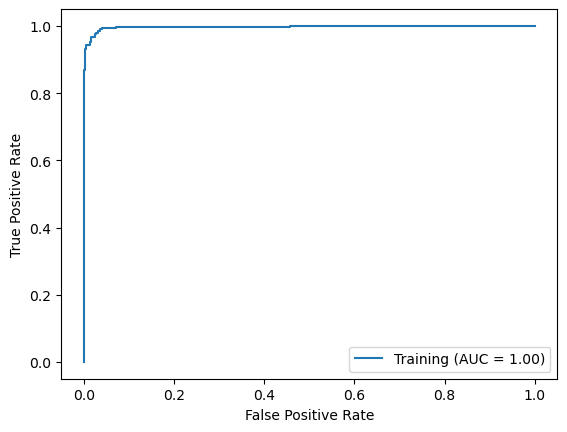

Testing Accuracy: 0.6878612716763006
Testing MCC Score: 0.3721774193548387
Testing F1 Score: 0.6860887096774194
Testing AUC VALUE: 0.7762096774193549
Testing kappa Score: 0.3721774193548387
Testing Precision: 0.6625
Testing Recall: 0.6625
Testing Sensitivity: 0.6625
Testing Specificity: 0.7096774193548387
Testing CCR: 0.6878612716763006
Testing PPV: 0.6625


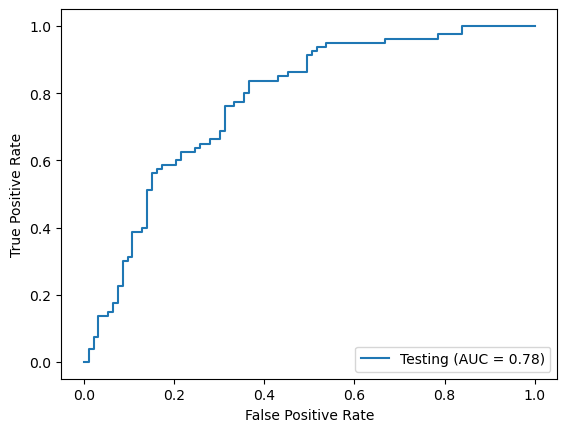

Fold # 1 Random Seed: 205
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:16:13,712:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:16:13,713:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:16:13,714:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 43
After filteration
Train shape
 (691, 43) 
Test shape
 (173, 43)
Before Oversampling
y_train_filtered
 0.0    385
1.0    306
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


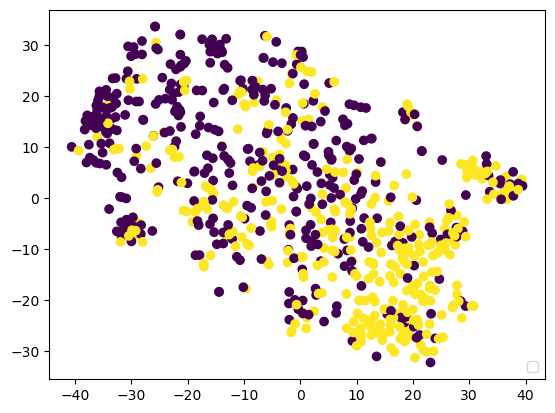

After Oversampling
Final_Ytrain
 0  
0.0    385
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9986301369863013
Training MCC Score: 0.9972553759689646
Training F1 Score: 0.9986258021644556
Training AUC VALUE: 1.0
Training kappa Score: 0.9972516095026542
Training Precision: 1.0
Training Recall: 0.9971014492753624
Training Sensitivity: 0.9971014492753624
Training Specificity: 1.0
Training CCR: 0.9986301369863013
Training PPV: 1.0


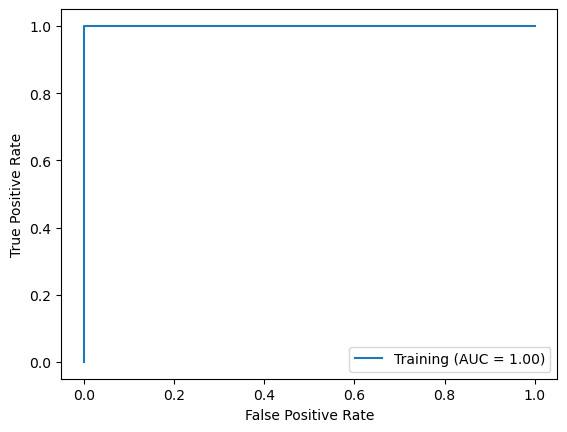

Testing Accuracy: 0.6705202312138728
Testing MCC Score: 0.35431117499992665
Testing F1 Score: 0.6689273124055732
Testing AUC VALUE: 0.7265060240963855
Testing kappa Score: 0.34578385192065275
Testing Precision: 0.7323943661971831
Testing Recall: 0.5777777777777777
Testing Sensitivity: 0.5777777777777777
Testing Specificity: 0.7710843373493976
Testing CCR: 0.6705202312138728
Testing PPV: 0.7323943661971831


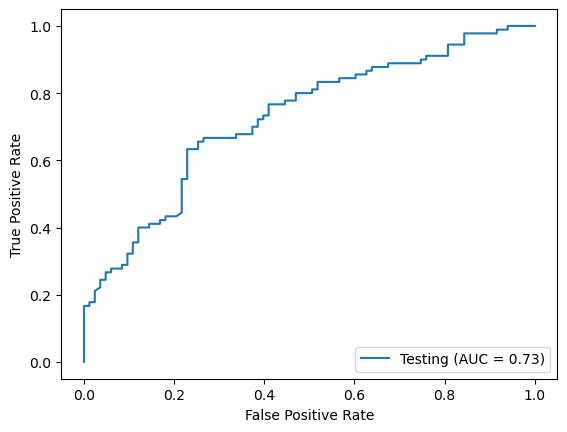

Fold # 2 Random Seed: 991
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:16:36,153:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:16:36,154:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:16:36,155:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 37
After filteration
Train shape
 (691, 37) 
Test shape
 (173, 37)
Before Oversampling
y_train_filtered
 0.0    377
1.0    314
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


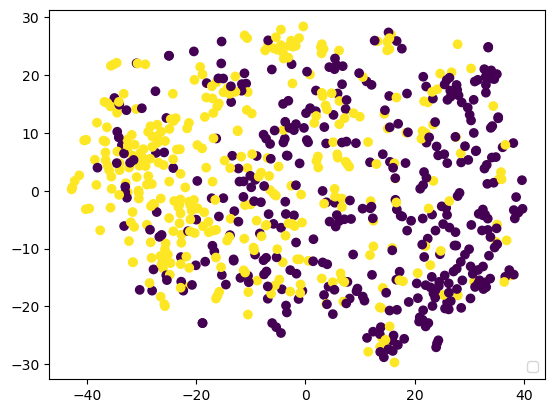

After Oversampling
Final_Ytrain
 0  
0.0    377
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9736842105263158
Training MCC Score: 0.9472749633863401
Training F1 Score: 0.9736356071132739
Training AUC VALUE: 0.996617076077346
Training kappa Score: 0.9472713155649173
Training Precision: 0.9710982658959537
Training Recall: 0.9739130434782609
Training Sensitivity: 0.9739130434782609
Training Specificity: 0.9734748010610079
Training CCR: 0.9736842105263158
Training PPV: 0.9710982658959537


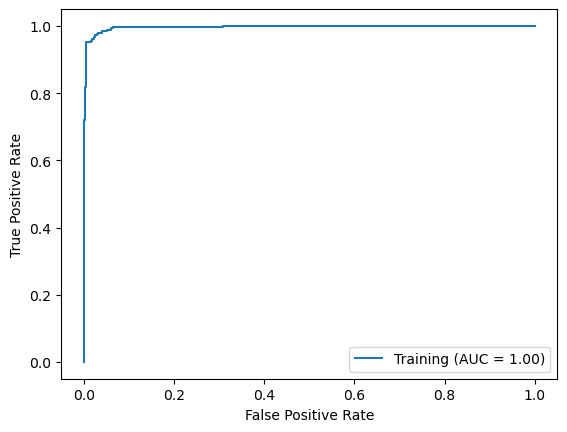

Testing Accuracy: 0.6878612716763006
Testing MCC Score: 0.37261516283394436
Testing F1 Score: 0.6848178137651821
Testing AUC VALUE: 0.759581881533101
Testing kappa Score: 0.3709938055480744
Testing Precision: 0.6891891891891891
Testing Recall: 0.6219512195121951
Testing Sensitivity: 0.6219512195121951
Testing Specificity: 0.7472527472527473
Testing CCR: 0.6878612716763006
Testing PPV: 0.6891891891891891


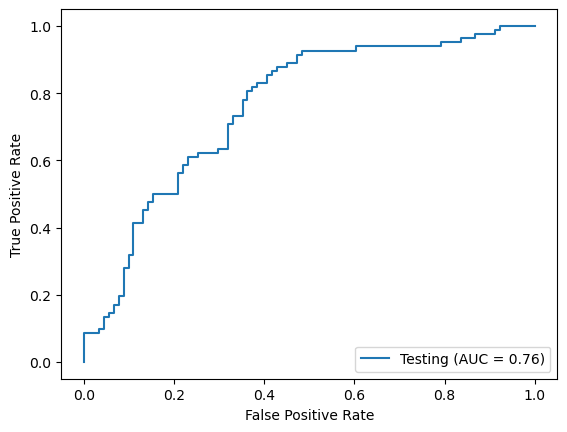

Fold # 3 Random Seed: 434
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:16:58,174:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:16:58,175:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:16:58,176:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 40
After filteration
Train shape
 (691, 40) 
Test shape
 (173, 40)
Before Oversampling
y_train_filtered
 0.0    375
1.0    316
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


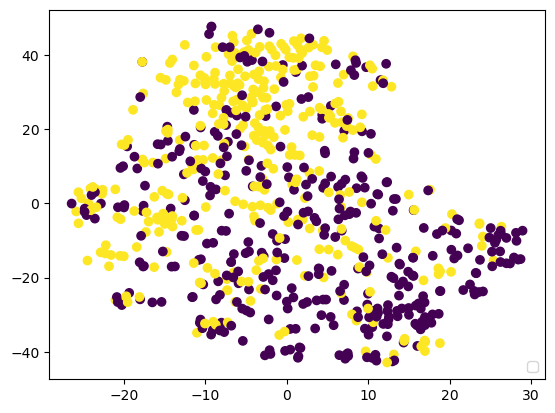

After Oversampling
Final_Ytrain
 0  
0.0    375
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9472222222222222
Training MCC Score: 0.8942608695652174
Training F1 Score: 0.9471304347826087
Training AUC VALUE: 0.9919072463768117
Training kappa Score: 0.8942608695652174
Training Precision: 0.9449275362318841
Training Recall: 0.9449275362318841
Training Sensitivity: 0.9449275362318841
Training Specificity: 0.9493333333333334
Training CCR: 0.9472222222222222
Training PPV: 0.9449275362318841


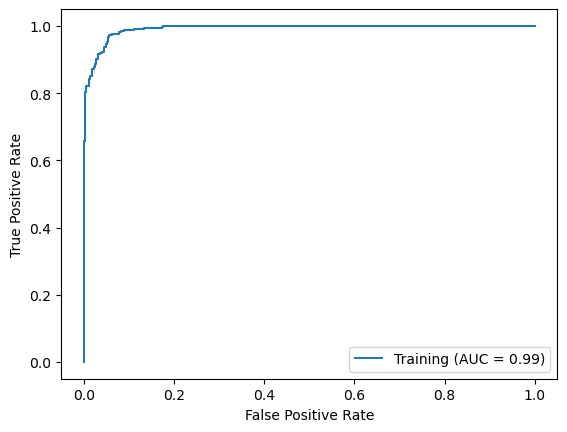

Testing Accuracy: 0.7109826589595376
Testing MCC Score: 0.41664522238371676
Testing F1 Score: 0.7074540043290043
Testing AUC VALUE: 0.7606182795698925
Testing kappa Score: 0.4156195108769085
Testing Precision: 0.7027027027027027
Testing Recall: 0.65
Testing Sensitivity: 0.65
Testing Specificity: 0.7634408602150538
Testing CCR: 0.7109826589595376
Testing PPV: 0.7027027027027027


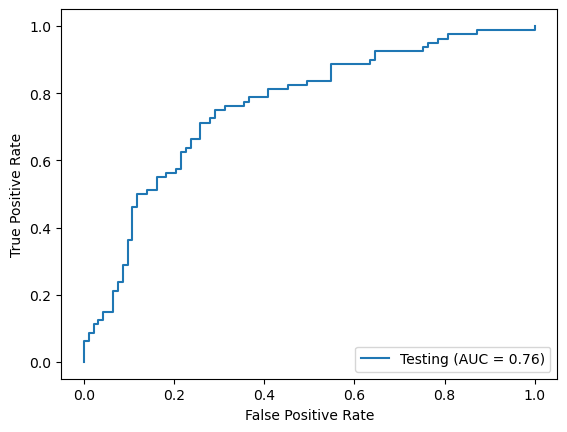

Fold # 4 Random Seed: 780
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:17:20,284:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:17:20,285:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:17:20,286:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 36
After filteration
Train shape
 (691, 36) 
Test shape
 (173, 36)
Before Oversampling
y_train_filtered
 0.0    367
1.0    324
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


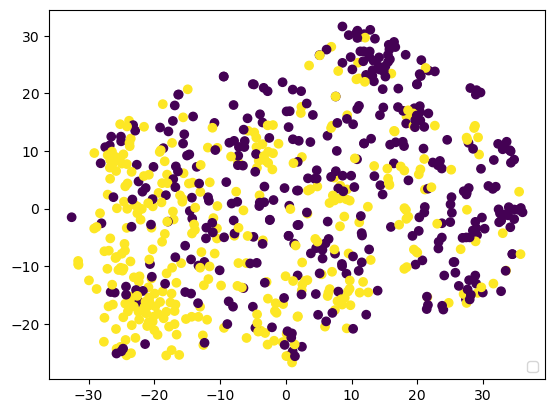

After Oversampling
Final_Ytrain
 0  
0.0    367
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9199438202247191
Training MCC Score: 0.8397227363834298
Training F1 Score: 0.9198449989038531
Training AUC VALUE: 0.9787071042135608
Training kappa Score: 0.8396928473242641
Training Precision: 0.9210526315789473
Training Recall: 0.9130434782608695
Training Sensitivity: 0.9130434782608695
Training Specificity: 0.9264305177111717
Training CCR: 0.9199438202247191
Training PPV: 0.9210526315789473


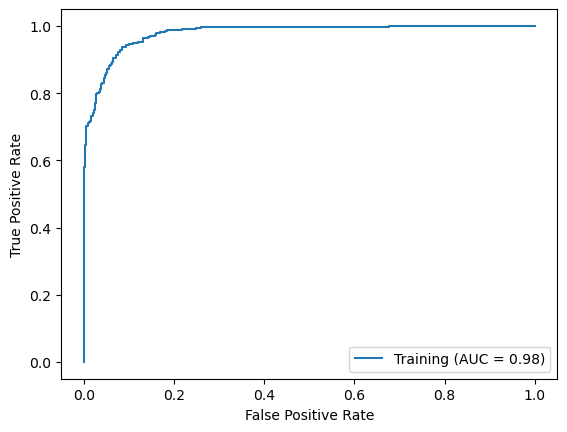

Testing Accuracy: 0.7283236994219653
Testing MCC Score: 0.439852117778033
Testing F1 Score: 0.719900788866306
Testing AUC VALUE: 0.7692519251925193
Testing kappa Score: 0.4398208749569411
Testing Precision: 0.676056338028169
Testing Recall: 0.6666666666666666
Testing Sensitivity: 0.6666666666666666
Testing Specificity: 0.7722772277227723
Testing CCR: 0.7283236994219653
Testing PPV: 0.676056338028169


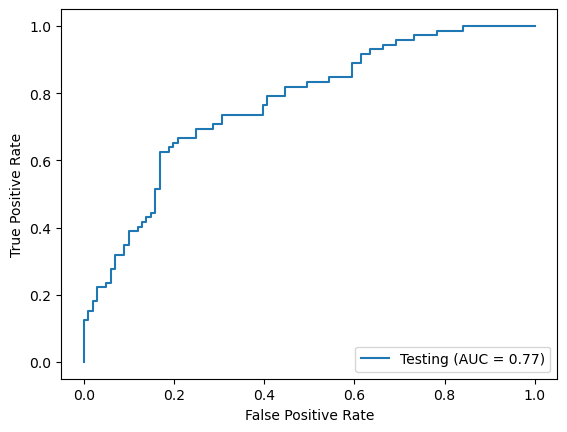

Fold # 5 Random Seed: 457
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:17:42,235:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:17:42,236:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:17:42,237:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 39
After filteration
Train shape
 (691, 39) 
Test shape
 (173, 39)
Before Oversampling
y_train_filtered
 0.0    376
1.0    315
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


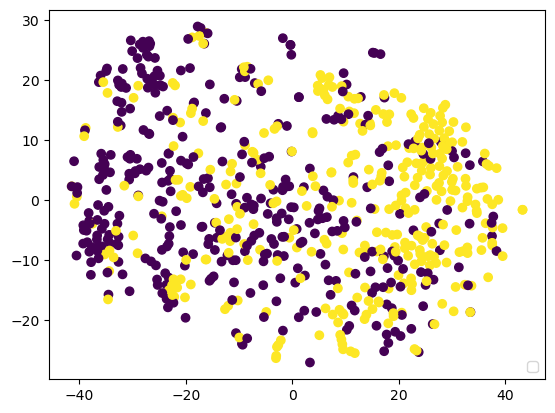

After Oversampling
Final_Ytrain
 0  
0.0    376
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9153952843273232
Training MCC Score: 0.830445274729146
Training F1 Score: 0.9152067246980344
Training AUC VALUE: 0.982277212457601
Training kappa Score: 0.830416391938214
Training Precision: 0.9152046783625731
Training Recall: 0.9072463768115943
Training Sensitivity: 0.9072463768115943
Training Specificity: 0.9228723404255319
Training CCR: 0.9153952843273232
Training PPV: 0.9152046783625731


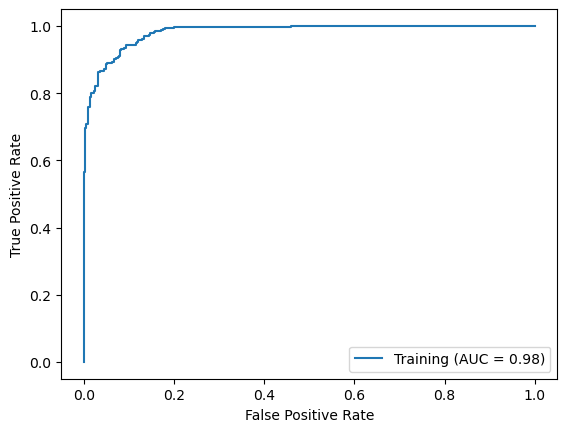

Testing Accuracy: 0.6878612716763006
Testing MCC Score: 0.37173572334092164
Testing F1 Score: 0.6854969027740372
Testing AUC VALUE: 0.7877079978529253
Testing kappa Score: 0.37133243606998645
Testing Precision: 0.6753246753246753
Testing Recall: 0.6419753086419753
Testing Sensitivity: 0.6419753086419753
Testing Specificity: 0.7282608695652174
Testing CCR: 0.6878612716763006
Testing PPV: 0.6753246753246753


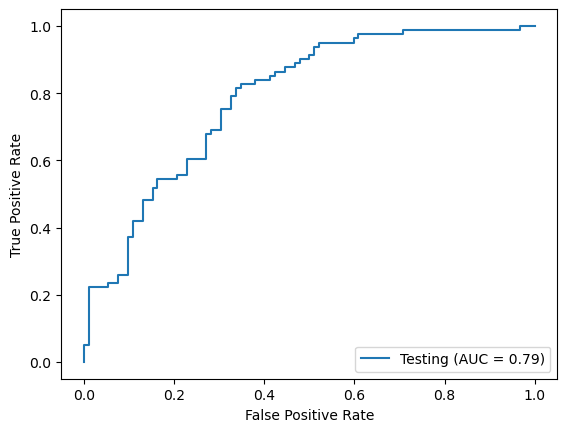

Fold # 6 Random Seed: 171
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:18:04,095:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:18:04,096:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:18:04,096:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 41
After filteration
Train shape
 (691, 41) 
Test shape
 (173, 41)
Before Oversampling
y_train_filtered
 0.0    371
1.0    320
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


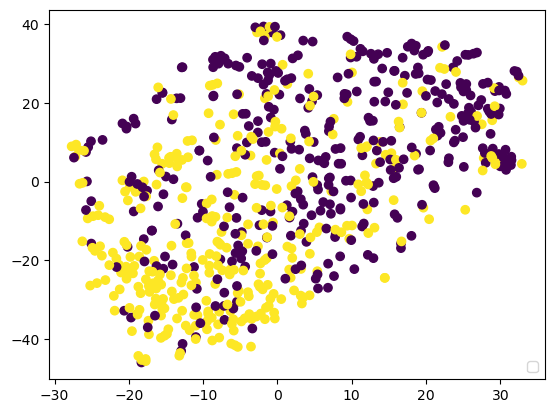

After Oversampling
Final_Ytrain
 0  
0.0    371
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.952513966480447
Training MCC Score: 0.9049977494510346
Training F1 Score: 0.952469092414267
Training AUC VALUE: 0.9919449978514785
Training kappa Score: 0.9049411544198614
Training Precision: 0.9455587392550143
Training Recall: 0.9565217391304348
Training Sensitivity: 0.9565217391304348
Training Specificity: 0.9487870619946092
Training CCR: 0.952513966480447
Training PPV: 0.9455587392550143


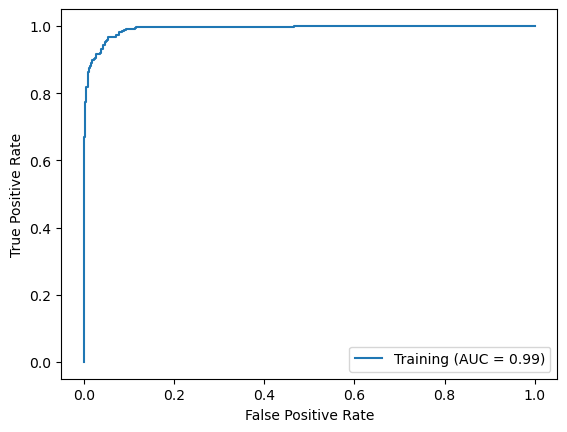

Testing Accuracy: 0.6705202312138728
Testing MCC Score: 0.3269597000124656
Testing F1 Score: 0.6629063685775818
Testing AUC VALUE: 0.7269397721106892
Testing kappa Score: 0.32638841450918776
Testing Precision: 0.6338028169014085
Testing Recall: 0.5921052631578947
Testing Sensitivity: 0.5921052631578947
Testing Specificity: 0.7319587628865979
Testing CCR: 0.6705202312138728
Testing PPV: 0.6338028169014085


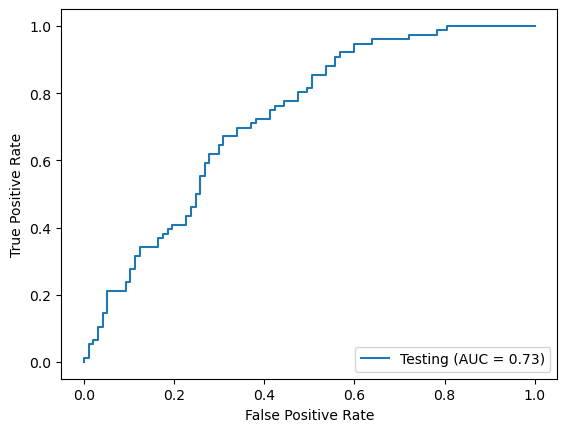

Fold # 7 Random Seed: 13
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:18:25,695:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:18:25,696:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:18:25,697:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 45
After filteration
Train shape
 (691, 45) 
Test shape
 (173, 45)
Before Oversampling
y_train_filtered
 0.0    377
1.0    314
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


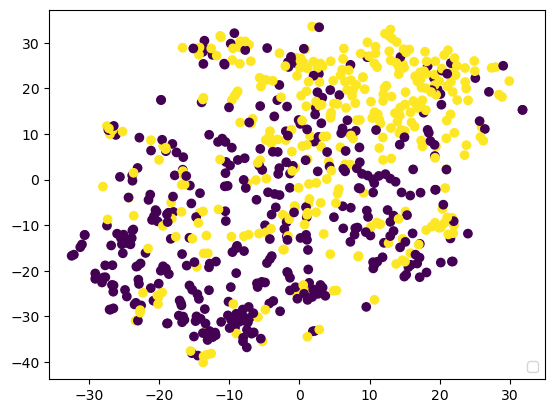

After Oversampling
Final_Ytrain
 0  
0.0    377
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8670360110803325
Training MCC Score: 0.7340288399732047
Training F1 Score: 0.8663427050792549
Training AUC VALUE: 0.9498712182370354
Training kappa Score: 0.7328914409033103
Training Precision: 0.8830769230769231
Training Recall: 0.8318840579710145
Training Sensitivity: 0.8318840579710145
Training Specificity: 0.8992042440318302
Training CCR: 0.8670360110803325
Training PPV: 0.8830769230769231


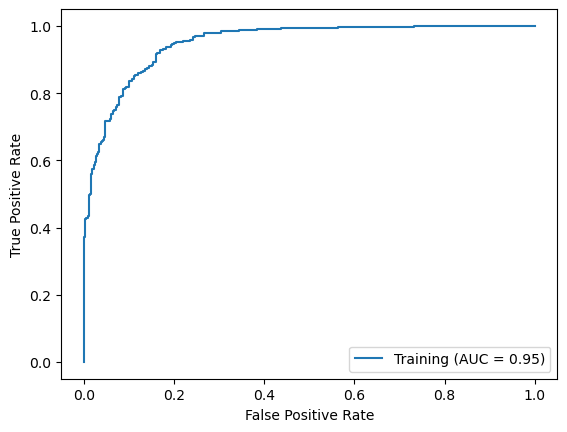

Testing Accuracy: 0.653179190751445
Testing MCC Score: 0.30242014667756795
Testing F1 Score: 0.6497975708502024
Testing AUC VALUE: 0.7079871348164031
Testing kappa Score: 0.30110422838674933
Testing Precision: 0.6486486486486487
Testing Recall: 0.5853658536585366
Testing Sensitivity: 0.5853658536585366
Testing Specificity: 0.7142857142857143
Testing CCR: 0.653179190751445
Testing PPV: 0.6486486486486487


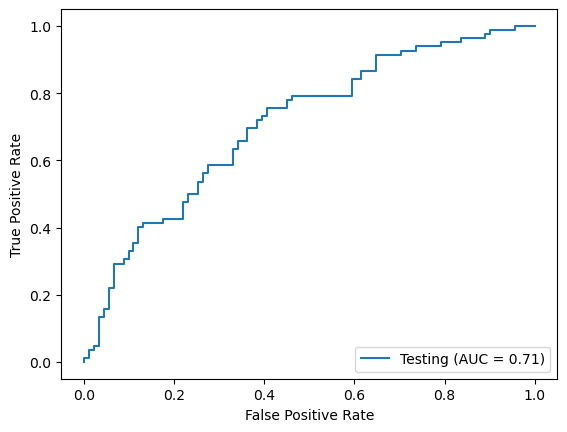

Fold # 8 Random Seed: 57
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:18:50,623:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:18:50,625:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:18:50,625:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 37
After filteration
Train shape
 (691, 37) 
Test shape
 (173, 37)
Before Oversampling
y_train_filtered
 0.0    377
1.0    314
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


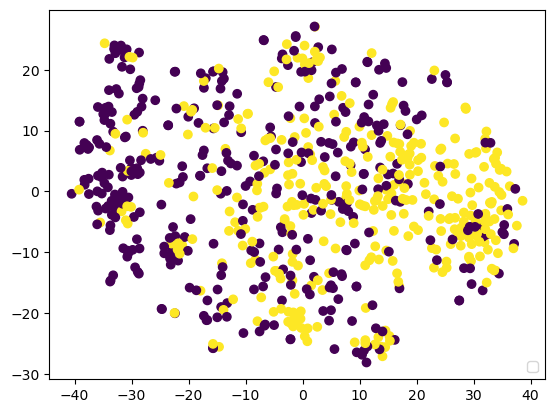

After Oversampling
Final_Ytrain
 0  
0.0    377
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9182825484764543
Training MCC Score: 0.836332799791389
Training F1 Score: 0.9181504987097531
Training AUC VALUE: 0.9827009572137008
Training kappa Score: 0.8363038282108628
Training Precision: 0.9109195402298851
Training Recall: 0.9188405797101449
Training Sensitivity: 0.9188405797101449
Training Specificity: 0.9177718832891246
Training CCR: 0.9182825484764543
Training PPV: 0.9109195402298851


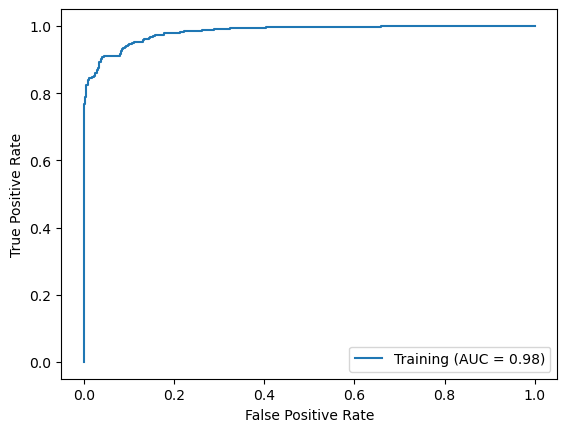

Testing Accuracy: 0.6820809248554913
Testing MCC Score: 0.36150025082728104
Testing F1 Score: 0.6805438979352023
Testing AUC VALUE: 0.7246046636290538
Testing kappa Score: 0.3612807947908975
Testing Precision: 0.6708860759493671
Testing Recall: 0.6463414634146342
Testing Sensitivity: 0.6463414634146342
Testing Specificity: 0.7142857142857143
Testing CCR: 0.6820809248554913
Testing PPV: 0.6708860759493671


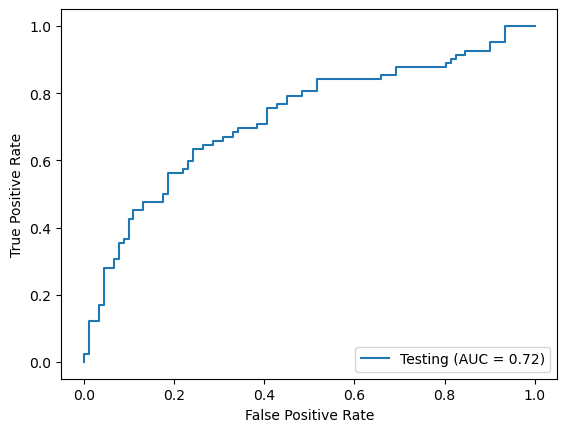

Fold # 9 Random Seed: 958
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:19:14,119:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:19:14,120:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:19:14,121:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 38
After filteration
Train shape
 (691, 38) 
Test shape
 (173, 38)
Before Oversampling
y_train_filtered
 0.0    372
1.0    319
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


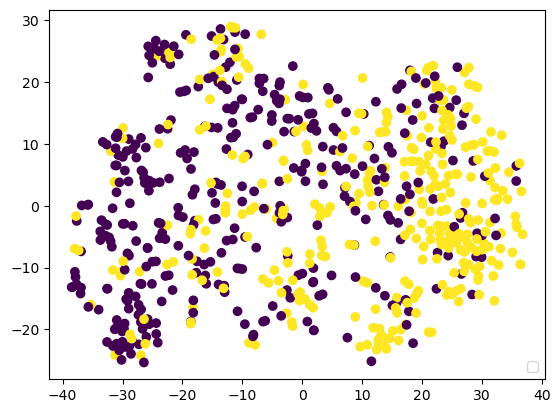

After Oversampling
Final_Ytrain
 0  
0.0    372
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9832635983263598
Training MCC Score: 0.9665540476777347
Training F1 Score: 0.9832463587506814
Training AUC VALUE: 0.9978884213807075
Training kappa Score: 0.9664937613907192
Training Precision: 0.9770773638968482
Training Recall: 0.9884057971014493
Training Sensitivity: 0.9884057971014493
Training Specificity: 0.978494623655914
Training CCR: 0.9832635983263598
Training PPV: 0.9770773638968482


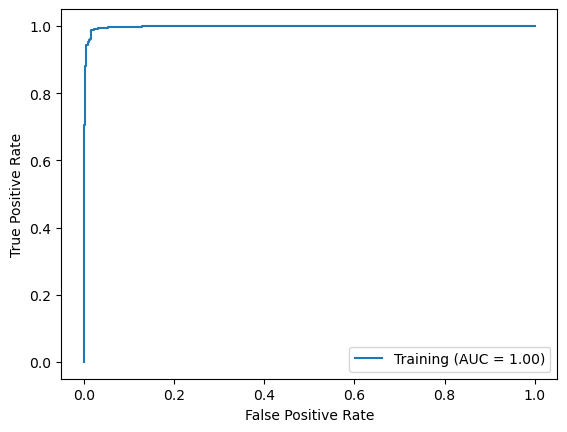

Testing Accuracy: 0.6473988439306358
Testing MCC Score: 0.28528880145328894
Testing F1 Score: 0.6426225066883402
Testing AUC VALUE: 0.6849296536796537
Testing kappa Score: 0.2852692177446664
Testing Precision: 0.6052631578947368
Testing Recall: 0.5974025974025974
Testing Sensitivity: 0.5974025974025974
Testing Specificity: 0.6875
Testing CCR: 0.6473988439306358
Testing PPV: 0.6052631578947368


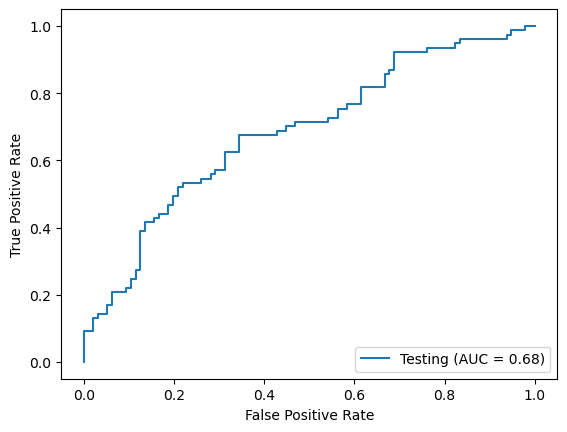

Fold # 10 Random Seed: 999
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:19:36,800:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:19:36,801:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:19:36,802:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 32
After filteration
Train shape
 (691, 32) 
Test shape
 (173, 32)
Before Oversampling
y_train_filtered
 0.0    372
1.0    319
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


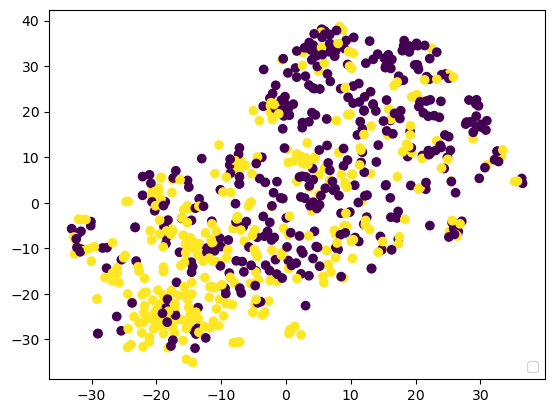

After Oversampling
Final_Ytrain
 0  
0.0    372
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9232914923291492
Training MCC Score: 0.846413978520603
Training F1 Score: 0.923118613932034
Training AUC VALUE: 0.9813152563503195
Training kappa Score: 0.8462519152718809
Training Precision: 0.9289940828402367
Training Recall: 0.9101449275362319
Training Sensitivity: 0.9101449275362319
Training Specificity: 0.9354838709677419
Training CCR: 0.9232914923291492
Training PPV: 0.9289940828402367


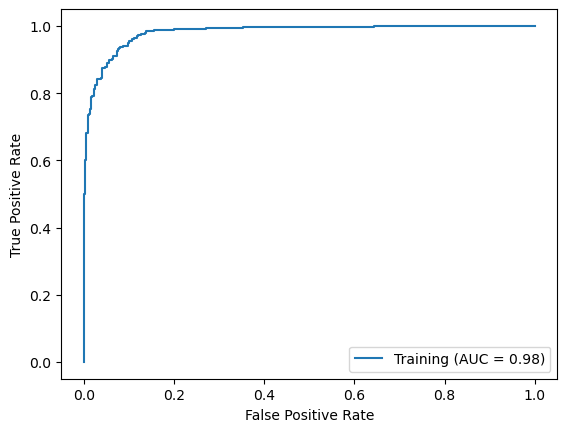

Testing Accuracy: 0.7283236994219653
Testing MCC Score: 0.44816322329471775
Testing F1 Score: 0.7238580404143318
Testing AUC VALUE: 0.782332251082251
Testing kappa Score: 0.4478848373735316
Testing Precision: 0.7027027027027027
Testing Recall: 0.6753246753246753
Testing Sensitivity: 0.6753246753246753
Testing Specificity: 0.7708333333333334
Testing CCR: 0.7283236994219653
Testing PPV: 0.7027027027027027


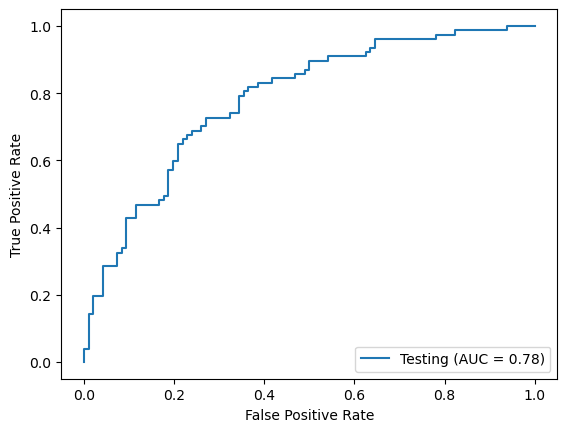

Fold # 11 Random Seed: 575
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:19:58,667:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:19:58,668:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:19:58,669:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 44
After filteration
Train shape
 (691, 44) 
Test shape
 (173, 44)
Before Oversampling
y_train_filtered
 0.0    378
1.0    313
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


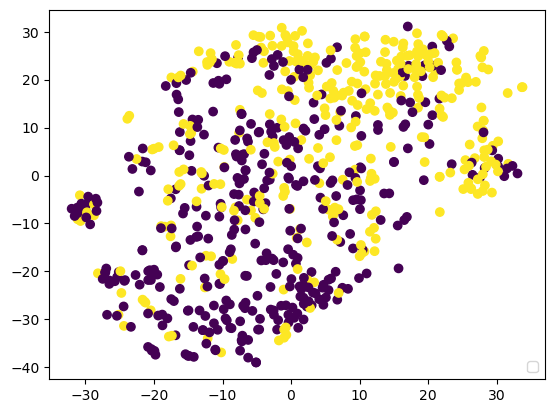

After Oversampling
Final_Ytrain
 0  
0.0    378
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9930843706777317
Training MCC Score: 0.9861454078772831
Training F1 Score: 0.9930707967146184
Training AUC VALUE: 0.999846637527797
Training kappa Score: 0.9861416199928695
Training Precision: 0.9913294797687862
Training Recall: 0.9942028985507246
Training Sensitivity: 0.9942028985507246
Training Specificity: 0.9920634920634921
Training CCR: 0.9930843706777317
Training PPV: 0.9913294797687862


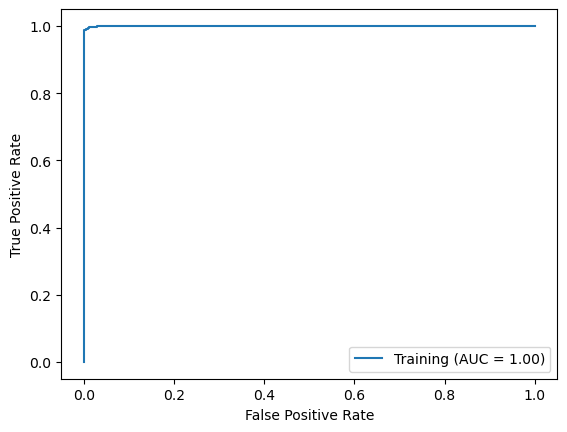

Testing Accuracy: 0.6069364161849711
Testing MCC Score: 0.21337797415644078
Testing F1 Score: 0.6066078116639915
Testing AUC VALUE: 0.6769745649263722
Testing kappa Score: 0.21332085060853279
Testing Precision: 0.5882352941176471
Testing Recall: 0.6024096385542169
Testing Sensitivity: 0.6024096385542169
Testing Specificity: 0.6111111111111112
Testing CCR: 0.6069364161849711
Testing PPV: 0.5882352941176471


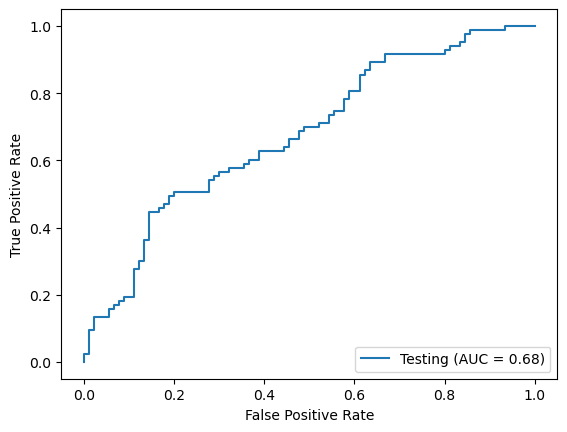

Fold # 12 Random Seed: 5
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:20:20,264:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:20:20,266:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:20:20,266:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 37
After filteration
Train shape
 (691, 37) 
Test shape
 (173, 37)
Before Oversampling
y_train_filtered
 0.0    387
1.0    304
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


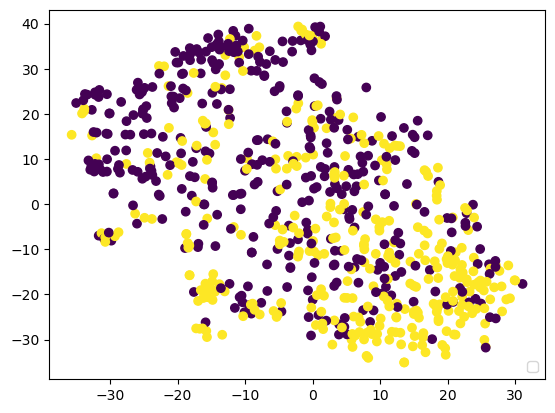

After Oversampling
Final_Ytrain
 0  
0.0    387
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8142076502732241
Training MCC Score: 0.6274061436237119
Training F1 Score: 0.8124929368421846
Training AUC VALUE: 0.9174100288357113
Training kappa Score: 0.6255388295831547
Training Precision: 0.8296529968454258
Training Recall: 0.7623188405797101
Training Sensitivity: 0.7623188405797101
Training Specificity: 0.8604651162790697
Training CCR: 0.8142076502732241
Training PPV: 0.8296529968454258


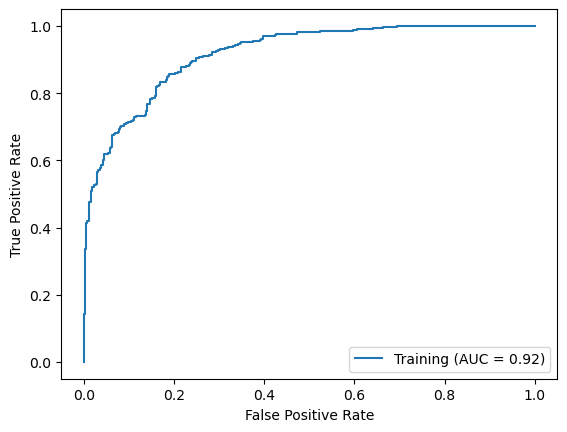

Testing Accuracy: 0.7109826589595376
Testing MCC Score: 0.4366108086127005
Testing F1 Score: 0.7105087014725568
Testing AUC VALUE: 0.7887144390767579
Testing kappa Score: 0.4272281816977884
Testing Precision: 0.7837837837837838
Testing Recall: 0.6304347826086957
Testing Sensitivity: 0.6304347826086957
Testing Specificity: 0.8024691358024691
Testing CCR: 0.7109826589595376
Testing PPV: 0.7837837837837838


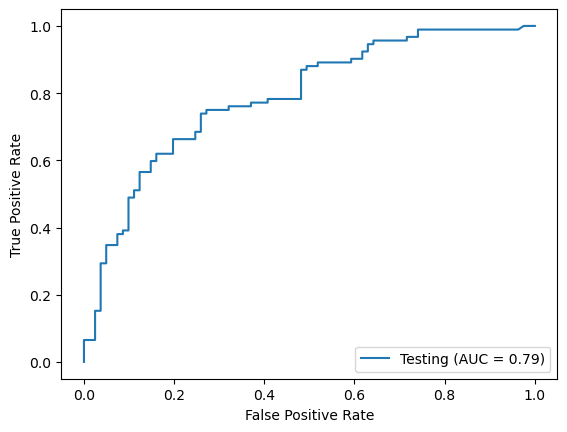

Fold # 13 Random Seed: 107
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:20:42,133:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:20:42,134:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:20:42,135:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 40
After filteration
Train shape
 (691, 40) 
Test shape
 (173, 40)
Before Oversampling
y_train_filtered
 0.0    379
1.0    312
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


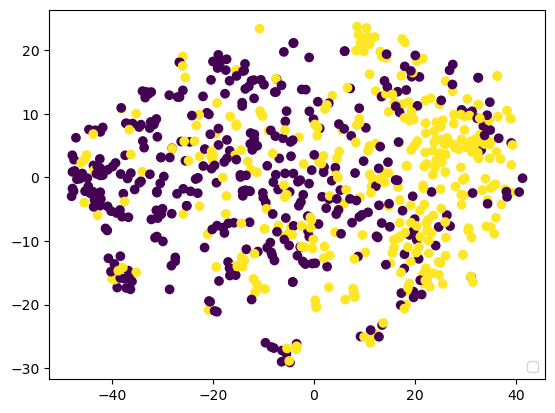

After Oversampling
Final_Ytrain
 0  
0.0    379
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9861878453038674
Training MCC Score: 0.9723599162000939
Training F1 Score: 0.9861496904723643
Training AUC VALUE: 0.9978738862758595
Training kappa Score: 0.9723002287909279
Training Precision: 0.9912023460410557
Training Recall: 0.9797101449275363
Training Sensitivity: 0.9797101449275363
Training Specificity: 0.9920844327176781
Training CCR: 0.9861878453038674
Training PPV: 0.9912023460410557


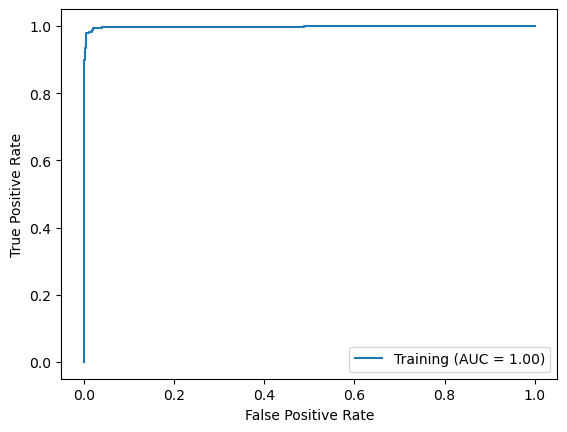

Testing Accuracy: 0.6647398843930635
Testing MCC Score: 0.3294321141205782
Testing F1 Score: 0.6614709851551956
Testing AUC VALUE: 0.7148876404494381
Testing kappa Score: 0.32621541767391893
Testing Precision: 0.6805555555555556
Testing Recall: 0.5833333333333334
Testing Sensitivity: 0.5833333333333334
Testing Specificity: 0.7415730337078652
Testing CCR: 0.6647398843930635
Testing PPV: 0.6805555555555556


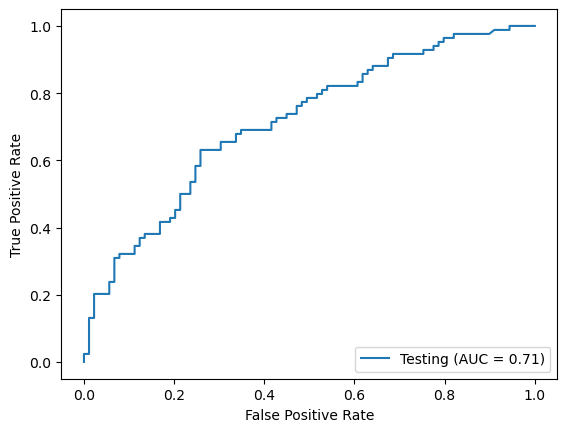

Fold # 14 Random Seed: 304
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:21:04,119:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:21:04,121:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:21:04,121:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 37
After filteration
Train shape
 (691, 37) 
Test shape
 (173, 37)
Before Oversampling
y_train_filtered
 0.0    373
1.0    318
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


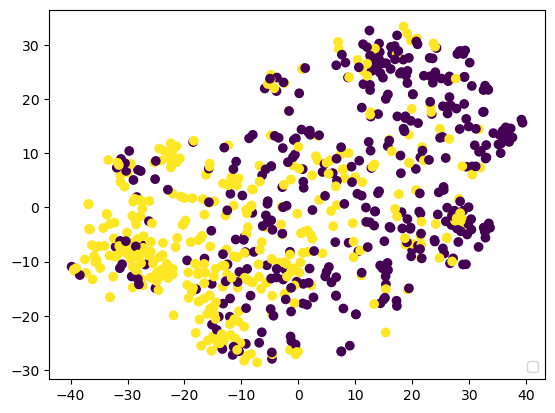

After Oversampling
Final_Ytrain
 0  
0.0    373
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.8899721448467967
Training MCC Score: 0.7798114418000621
Training F1 Score: 0.8896121967215667
Training AUC VALUE: 0.9733846213622412
Training kappa Score: 0.7792969813934305
Training Precision: 0.9006024096385542
Training Recall: 0.8666666666666667
Training Sensitivity: 0.8666666666666667
Training Specificity: 0.9115281501340483
Training CCR: 0.8899721448467967
Training PPV: 0.9006024096385542


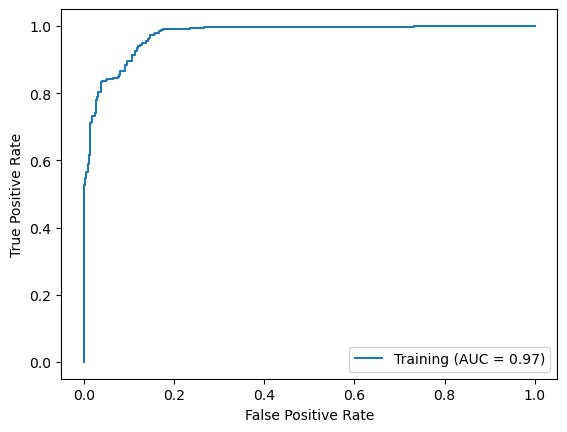

Testing Accuracy: 0.6705202312138728
Testing MCC Score: 0.33252307261258446
Testing F1 Score: 0.666057096413695
Testing AUC VALUE: 0.7265856950067476
Testing kappa Score: 0.3323176924639448
Testing Precision: 0.64
Testing Recall: 0.6153846153846154
Testing Sensitivity: 0.6153846153846154
Testing Specificity: 0.7157894736842105
Testing CCR: 0.6705202312138728
Testing PPV: 0.64


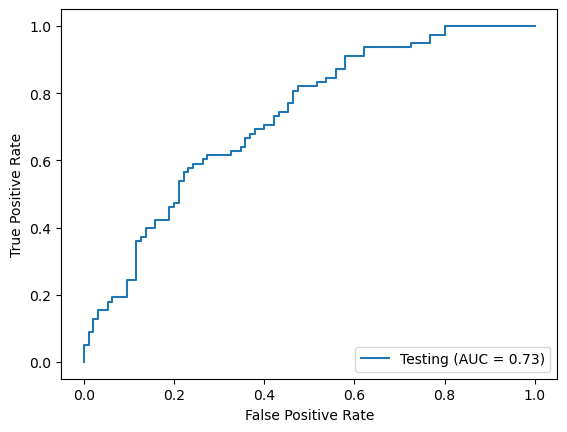

Fold # 15 Random Seed: 199
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:21:25,503:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:21:25,505:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:21:25,505:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 43
After filteration
Train shape
 (691, 43) 
Test shape
 (173, 43)
Before Oversampling
y_train_filtered
 0.0    374
1.0    317
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


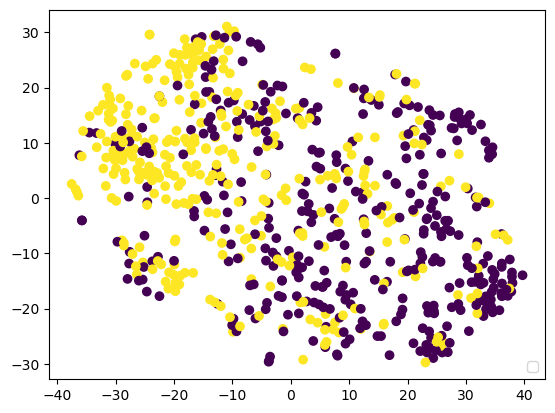

After Oversampling
Final_Ytrain
 0  
0.0    374
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9151599443671766
Training MCC Score: 0.8300677334774219
Training F1 Score: 0.9149467192848071
Training AUC VALUE: 0.9766178408122143
Training kappa Score: 0.8299096010579508
Training Precision: 0.9201183431952663
Training Recall: 0.9014492753623189
Training Sensitivity: 0.9014492753623189
Training Specificity: 0.9278074866310161
Training CCR: 0.9151599443671766
Training PPV: 0.9201183431952663


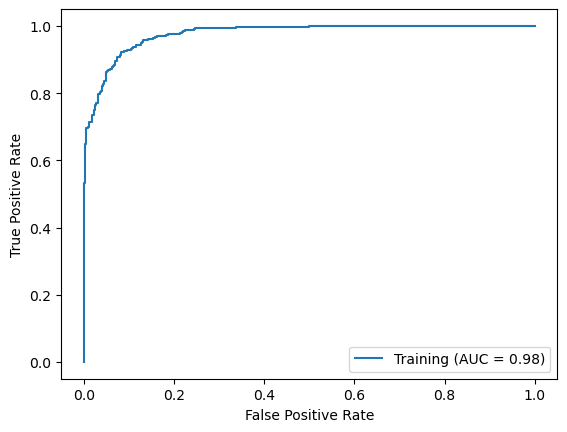

Testing Accuracy: 0.6763005780346821
Testing MCC Score: 0.350699703939319
Testing F1 Score: 0.6749865807836822
Testing AUC VALUE: 0.7290600592512794
Testing kappa Score: 0.35032188841201717
Testing Precision: 0.6385542168674698
Testing Recall: 0.6708860759493671
Testing Sensitivity: 0.6708860759493671
Testing Specificity: 0.6808510638297872
Testing CCR: 0.6763005780346821
Testing PPV: 0.6385542168674698


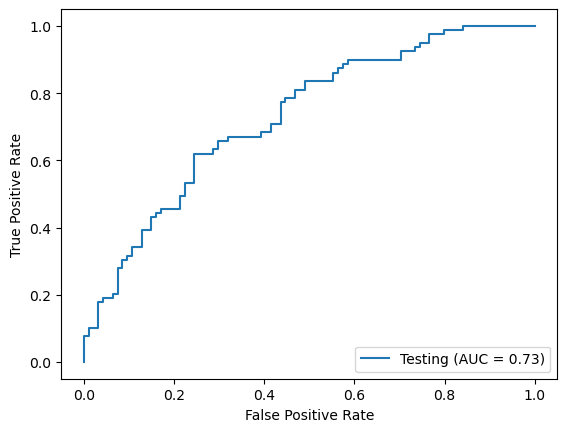

Fold # 16 Random Seed: 78
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:21:47,928:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:21:47,929:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:21:47,930:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 29
After filteration
Train shape
 (691, 29) 
Test shape
 (173, 29)
Before Oversampling
y_train_filtered
 0.0    374
1.0    317
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


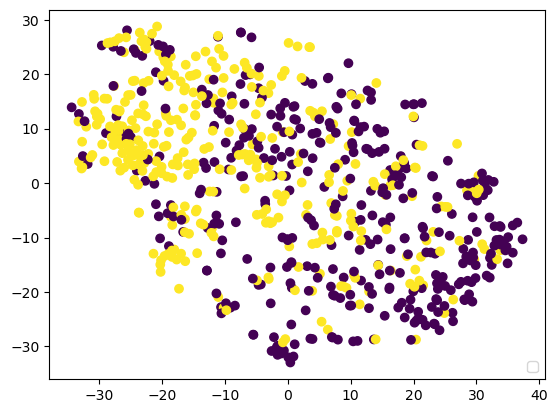

After Oversampling
Final_Ytrain
 0  
0.0    374
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.7969401947148818
Training MCC Score: 0.5929917142803267
Training F1 Score: 0.7963409902219463
Training AUC VALUE: 0.9034488103541812
Training kappa Score: 0.5927609884781007
Training Precision: 0.7970149253731343
Training Recall: 0.7739130434782608
Training Sensitivity: 0.7739130434782608
Training Specificity: 0.8181818181818182
Training CCR: 0.7969401947148818
Training PPV: 0.7970149253731343


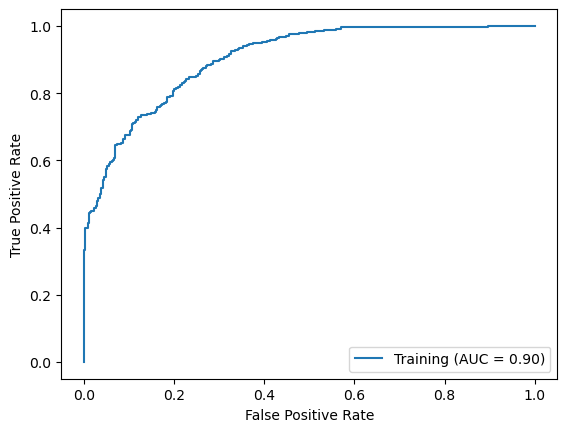

Testing Accuracy: 0.7225433526011561
Testing MCC Score: 0.4382233884678694
Testing F1 Score: 0.7166257166257167
Testing AUC VALUE: 0.7970643684352274
Testing kappa Score: 0.4351788872262278
Testing Precision: 0.7246376811594203
Testing Recall: 0.6329113924050633
Testing Sensitivity: 0.6329113924050633
Testing Specificity: 0.7978723404255319
Testing CCR: 0.7225433526011561
Testing PPV: 0.7246376811594203


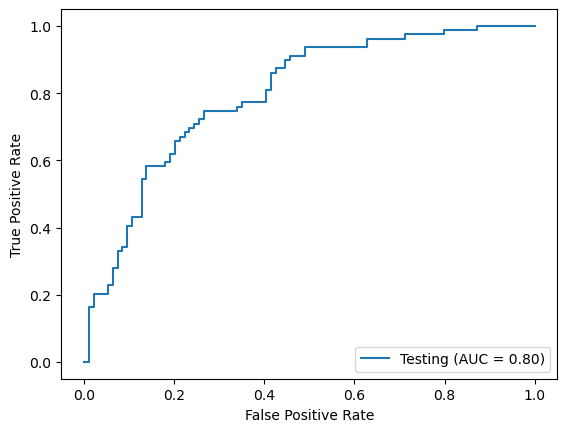

Fold # 17 Random Seed: 69
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:22:09,288:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:22:09,289:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:22:09,290:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 39
After filteration
Train shape
 (691, 39) 
Test shape
 (173, 39)
Before Oversampling
y_train_filtered
 0.0    382
1.0    309
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


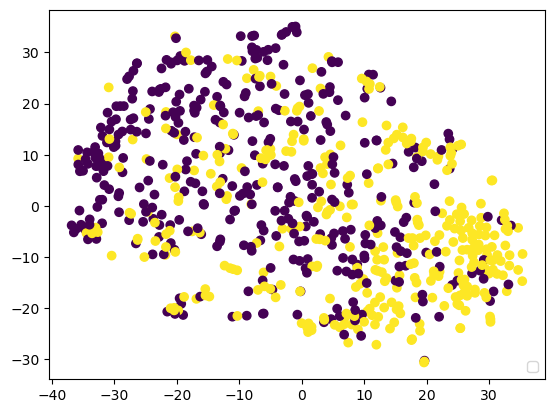

After Oversampling
Final_Ytrain
 0  
0.0    382
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9876203576341128
Training MCC Score: 0.975220224510762
Training F1 Score: 0.9875932214959809
Training AUC VALUE: 0.9990211700432506
Training kappa Score: 0.9751868664459538
Training Precision: 0.9827586206896551
Training Recall: 0.991304347826087
Training Sensitivity: 0.991304347826087
Training Specificity: 0.9842931937172775
Training CCR: 0.9876203576341128
Training PPV: 0.9827586206896551


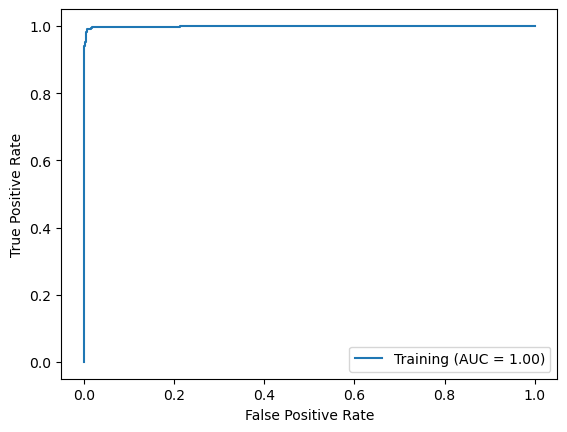

Testing Accuracy: 0.6878612716763006
Testing MCC Score: 0.3893853442305103
Testing F1 Score: 0.6831931633206729
Testing AUC VALUE: 0.7706495589414596
Testing kappa Score: 0.37661817696516753
Testing Precision: 0.7538461538461538
Testing Recall: 0.5632183908045977
Testing Sensitivity: 0.5632183908045977
Testing Specificity: 0.813953488372093
Testing CCR: 0.6878612716763006
Testing PPV: 0.7538461538461538


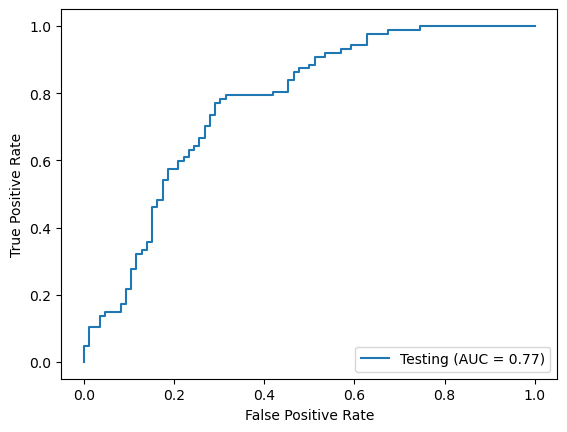

Fold # 18 Random Seed: 605
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:22:32,130:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:22:32,131:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:22:32,132:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 43
After filteration
Train shape
 (691, 43) 
Test shape
 (173, 43)
Before Oversampling
y_train_filtered
 0.0    375
1.0    316
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


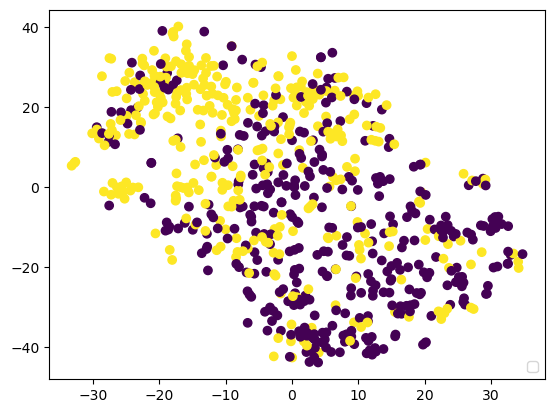

After Oversampling
Final_Ytrain
 0  
0.0    375
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9333333333333333
Training MCC Score: 0.8664172272924247
Training F1 Score: 0.9332013854527461
Training AUC VALUE: 0.9858782608695653
Training kappa Score: 0.8664038037805868
Training Precision: 0.9329446064139941
Training Recall: 0.927536231884058
Training Sensitivity: 0.927536231884058
Training Specificity: 0.9386666666666666
Training CCR: 0.9333333333333333
Training PPV: 0.9329446064139941


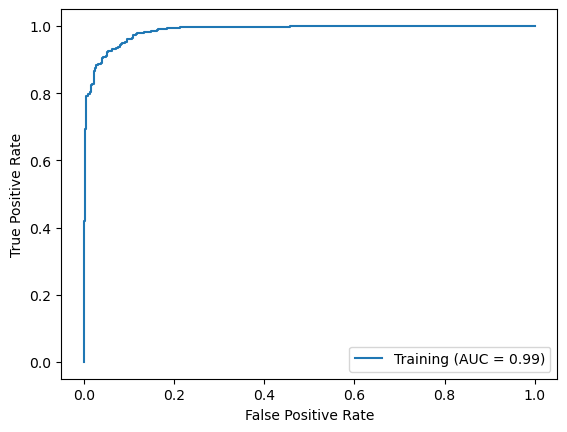

Testing Accuracy: 0.6358381502890174
Testing MCC Score: 0.26577809081799897
Testing F1 Score: 0.6326963906581742
Testing AUC VALUE: 0.701747311827957
Testing kappa Score: 0.26561552456033954
Testing Precision: 0.6103896103896104
Testing Recall: 0.5875
Testing Sensitivity: 0.5875
Testing Specificity: 0.6774193548387096
Testing CCR: 0.6358381502890174
Testing PPV: 0.6103896103896104


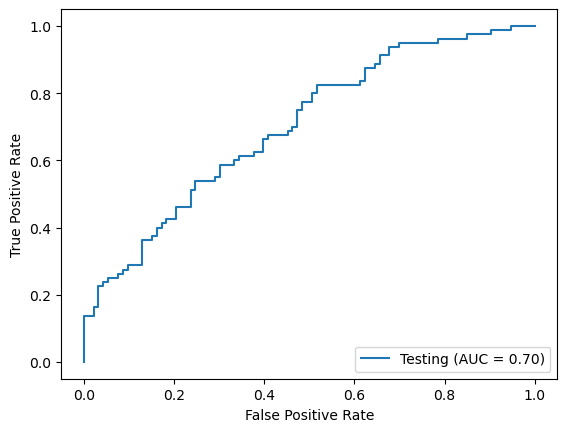

Fold # 19 Random Seed: 626
Before filteration
Train shape
 (691, 3200) 
Test shape
 (173, 3200)


2024-11-04 22:22:55,536:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:22:55,537:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:22:55,538:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 41
After filteration
Train shape
 (691, 41) 
Test shape
 (173, 41)
Before Oversampling
y_train_filtered
 0.0    368
1.0    323
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


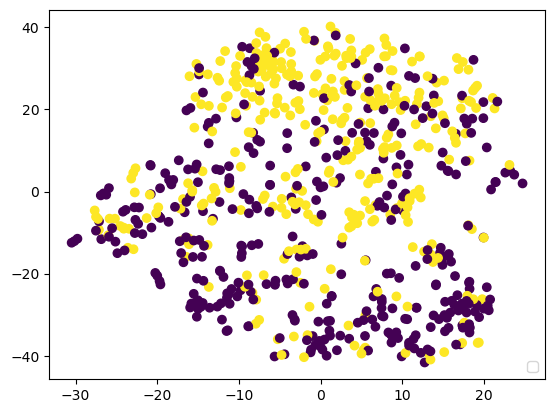

After Oversampling
Final_Ytrain
 0  
0.0    368
1.0    345
Name: count, dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9957924263674615
Training MCC Score: 0.9915807583816392
Training F1 Score: 0.9957884166691278
Training AUC VALUE: 0.9996691871455576
Training kappa Score: 0.9915768499230142
Training Precision: 0.9942196531791907
Training Recall: 0.9971014492753624
Training Sensitivity: 0.9971014492753624
Training Specificity: 0.9945652173913043
Training CCR: 0.9957924263674615
Training PPV: 0.9942196531791907


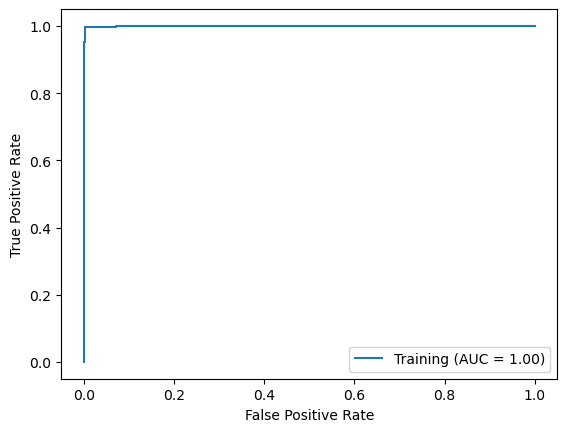

Testing Accuracy: 0.6242774566473989
Testing MCC Score: 0.24044503835141948
Testing F1 Score: 0.6191879169629857
Testing AUC VALUE: 0.7341095890410959
Testing kappa Score: 0.23963756846304685
Testing Precision: 0.55
Testing Recall: 0.6027397260273972
Testing Sensitivity: 0.6027397260273972
Testing Specificity: 0.64
Testing CCR: 0.6242774566473989
Testing PPV: 0.55


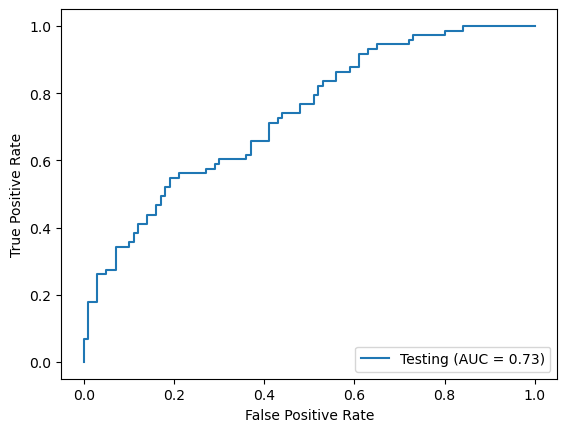

In [28]:
Train_Fold_outs=[]
Test_Fold_outs=[]
Best_params=[]
features = []
models=[]

#this chunk runs 20 iterations of the 5-Cross Validation of the pre-defined grid for the model
for i in range(20):
    #print('Fold #',i)   
    seed = random.randint(0, 1000)
    print('Fold #', i, "Random Seed:", seed)
    
    # Split Data
    X_train, X_test,y_train,y_test = train_test_split(Train,Train["status"] ,test_size=0.20, shuffle = True, random_state=seed)
    
    #Drop smiles,status from training,testing data
    x_train = X_train.drop(['status','smiles'], axis=1)
    x_test = X_test.drop(['status','smiles'], axis=1)

    #Feature selection
    x_train_filtered,x_test_filtered,y_train_filtered,y_test_filtered,selected_features = Boruta_Filteration(x_train,y_train,x_test,y_test)
    features.append(selected_features)
    
    y_train_filtered = pd.Series(y_train_filtered)

    print('Before Oversampling\ny_train_filtered\n',y_train_filtered.value_counts())
    #Oversampling
    Final_Xtrain,Final_Ytrain = Smote(x_train_filtered,y_train_filtered,0.5)
    print('After Oversampling\nFinal_Ytrain\n',Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)
    
    #Hyperparameter Tuning
    Parameters = HPTing_Model(Final_Xtrain,Final_Ytrain)
    
    #save best parameters
    Best_params.append(Parameters.best_estimator_.get_params())
    
    #build the tuned model
    #edit the parameters here according to your defined parameter space and model's grid
    rf = RandomForestClassifier(max_features=Parameters.best_estimator_.get_params()['max_features'],
                        max_depth=Parameters.best_estimator_.get_params()['max_depth'],
                        min_samples_split=Parameters.best_estimator_.get_params()['min_samples_split'],
                        min_samples_leaf=Parameters.best_estimator_.get_params()['min_samples_leaf'],
                        bootstrap=Parameters.best_estimator_.get_params()['bootstrap'],
                        n_estimators=Parameters.best_estimator_.get_params()['n_estimators'])

    
    #fit the built model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models.append(rf)

    #Training Predictions for the model
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)

    #Save training metrics
    Train_Fold_outs.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain,'Training'))

    #Testing Predictions for the model
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)

    #Save testing metrics
    Test_Fold_outs.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered,'Testing'))

In [29]:
#Analyse the testing metrics sorted by descending Testing Accuracy
pd.DataFrame.from_dict(Test_Fold_outs).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
10,0.728324,0.448163,0.723858,0.782332,0.447885,0.702703,0.675325,0.675325,0.770833,0.728324,0.702703
4,0.728324,0.439852,0.719901,0.769252,0.439821,0.676056,0.666667,0.666667,0.772277,0.728324,0.676056
16,0.722543,0.438223,0.716626,0.797064,0.435179,0.724638,0.632911,0.632911,0.797872,0.722543,0.724638
12,0.710983,0.436611,0.710509,0.788714,0.427228,0.783784,0.630435,0.630435,0.802469,0.710983,0.783784
3,0.710983,0.416645,0.707454,0.760618,0.415620,0.702703,0.650000,0.650000,0.763441,0.710983,0.702703
17,0.687861,0.389385,0.683193,0.770650,0.376618,0.753846,0.563218,0.563218,0.813953,0.687861,0.753846
0,0.687861,0.372177,0.686089,0.776210,0.372177,0.662500,0.662500,0.662500,0.709677,0.687861,0.662500
5,0.687861,0.371736,0.685497,0.787708,0.371332,0.675325,0.641975,0.641975,0.728261,0.687861,0.675325
2,0.687861,0.372615,0.684818,0.759582,0.370994,0.689189,0.621951,0.621951,0.747253,0.687861,0.689189
8,0.682081,0.361500,0.680544,0.724605,0.361281,0.670886,0.646341,0.646341,0.714286,0.682081,0.670886


In [30]:
#View the best parameters
pd.DataFrame.from_dict(Best_params)

,bootstrap,ccp_alpha,class_weight,criterion,max_depth,max_features,max_leaf_nodes,max_samples,min_impurity_decrease,min_samples_leaf,min_samples_split,min_weight_fraction_leaf,n_estimators,n_jobs,oob_score,random_state,verbose,warm_start
0,False,0.0,None,gini,70.0,sqrt,None,None,0.0,2,27,0.0,23,None,False,None,0,False
1,False,0.0,None,gini,110.0,log2,None,None,0.0,3,4,0.0,56,None,False,None,0,False
2,True,0.0,None,gini,60.0,sqrt,None,None,0.0,2,12,0.0,100,None,False,None,0,False
3,False,0.0,None,gini,10.0,log2,None,None,0.0,8,23,0.0,78,None,False,None,0,False
4,False,0.0,None,gini,40.0,log2,None,None,0.0,12,12,0.0,23,None,False,None,0,False
5,True,0.0,None,gini,70.0,None,None,None,0.0,8,14,0.0,56,None,False,None,0,False
6,False,0.0,None,gini,80.0,sqrt,None,None,0.0,5,27,0.0,100,None,False,None,0,False
7,True,0.0,None,gini,50.0,sqrt,None,None,0.0,10,14,0.0,56,None,False,None,0,False
8,True,0.0,None,gini,20.0,None,None,None,0.0,3,29,0.0,100,None,False,None,0,False
9,False,0.0,None,gini,40.0,log2,None,None,0.0,3,20,0.0,100,None,False,None,0,False


In [31]:
#View length of the features selected for the top performing/most stable (selected) model (1st here)
len(features[10])

32

In [32]:
#Save the feature names
pd.DataFrame(features[10]).to_csv('AID_1199_features.csv',index=False)

In [33]:
#save the best parameters of the chosen model
with open('AID_1199_best_params_RF.csv', 'w') as f:  # You will need 'wb' mode in Python 2.x
    w = csv.DictWriter(f, Best_params[10].keys())
    w.writeheader()
    w.writerow(Best_params[10])

In [34]:
"""
#Randomly split the data into testing and validation for each fold
def Test_valid_split(Set3,frac,seed):
    Fraction=frac
    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))
    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]
    Valid=Set3.T[Valid_index].T
    print('Test set size:',len(Test),'\nValid set size:',len(Valid))
    return Test,Valid
"""

"\n#Randomly split the data into testing and validation for each fold\ndef Test_valid_split(Set3,frac,seed):\n    Fraction=frac\n    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))\n    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]\n    Valid=Set3.T[Valid_index].T\n    print('Test set size:',len(Test),'\nValid set size:',len(Valid))\n    return Test,Valid\n"

In [35]:
def Test_valid_split(Set3, frac, seed):
    Fraction = frac
    Test_1 = Set3[Set3['status'] == 1].sample(frac=Fraction, random_state=1)
    Test_0 = Set3[Set3['status'] == 0].sample(frac=Fraction, random_state=seed)
    
    # 使用 pd.concat 代替 append
    Test = pd.concat([Test_1, Test_0])
    
    Valid_index = [item for item in list(Set3.index) if item not in list(Test.index)]
    Valid = Set3.T[Valid_index].T
    print('Test set size:', len(Test), '\nValid set size:', len(Valid))
    
    return Test, Valid

In [36]:
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv('AID_1199_features.csv')

# 假设第一列名为 'Features'
f_list = df['Features'].tolist()

# 输出 f_list 确认结果
print(f_list)

['A1_42', 'A4_125', 'B2_52', 'B3_1', 'B3_56', 'C1_73', 'C1_95', 'D1_64', 'D1_78', 'D1_97', 'D4_3', 'D4_69', 'D5_102', 'E1_31', 'E1_96', 'E1_103', 'E4_5', 'E4_6', 'E4_15', 'E4_17', 'E4_22', 'E4_23', 'E4_35', 'E4_37', 'E4_70', 'E4_74', 'E4_79', 'E4_89', 'E4_116', 'E4_117', 'E4_122', 'E4_125']


In [37]:
''' 
#f_list=features[1] #feature list of the selected (hyperparameter tuned) model
Train_Fold_outs_1=[]
Test_Fold_outs_1=[]
models_1=[]

# 用于存储训练和测试集的预测结果和标签
total_metrics= []


Parameters = pd.DataFrame.from_dict(Best_params).iloc[3].to_dict()
print(Parameters)
for i in range(20):
    print('Fold #',i)
    
    #Train-test split randomly
    Trn,Tst = Test_valid_split(Data,0.9,i)
    Train_y, Test_y = Trn['status'],Tst['status']

    #Use selected feature list
    Train_x = Trn[f_list]
    Test_x = Tst[f_list]
    print(Trn[f_list].shape)
    
    x_train_filtered = Train_x.values
    x_test_filtered = Test_x.values
    y_train_filtered = Train_y.values.ravel()
    y_test_filtered = Test_y.values.ravel()

    print(Train_y.value_counts())
    #Upsampling
    Final_Xtrain,Final_Ytrain = Smote(Train_x,Train_y,0.5)
    print(Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)

    #Use the best parameters from the chosen model here

    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])


    
    #Fit the model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models_1.append(rf)
    
    #Training prediction and saving the metrics
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain.astype('int'),'Training'))

    #Testing prediction and saving the metrics
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered.astype('int'),'Testing'))
'''
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob[:, 1])
    all_labels.extend(Final_Ytrain.astype('int'))
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob[:, 1])
    all_labels.extend(y_test_filtered.astype('int'))

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob[:, 1])\n    all_labels.extend(Final_Ytrain.astype('int'))\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob[:, 1])\n    all_labels.extend(y_test_filtered.astype('int'))\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [38]:
y_train_prob

array([[0.12133519, 0.87866481],
       [0.24183083, 0.75816917],
       [0.85791072, 0.14208928],
       ...,
       [0.25960809, 0.74039191],
       [0.06918179, 0.93081821],
       [0.06914287, 0.93085713]])

2024-11-04 22:26:44,518:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:26:44,519:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:26:44,520:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 90.0, 'max_features': 'log2', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 12, 'min_samples_split': 18, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 56, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Fold #1


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


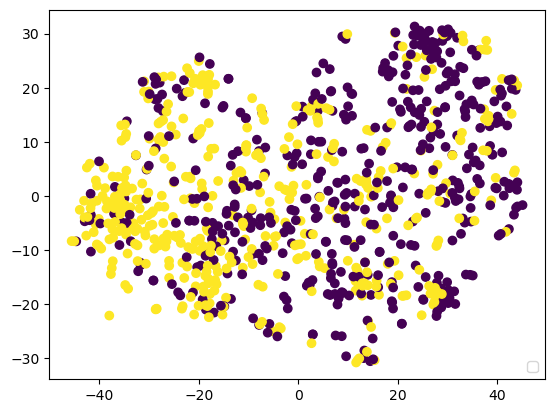

0  
0.0    473
1.0    432
Name: count, dtype: int64
Training Accuracy: 0.9337016574585635
Training MCC Score: 0.8671601919913133
Training F1 Score: 0.9335067301475343
Training AUC VALUE: 0.98580524234594
Training kappa Score: 0.8670238818251278
Training Precision: 0.9386792452830188
Training Recall: 0.9212962962962963
Training Sensitivity: 0.9212962962962963
Training Specificity: 0.945031712473573
Training CCR: 0.9337016574585635
Training PPV: 0.9386792452830188


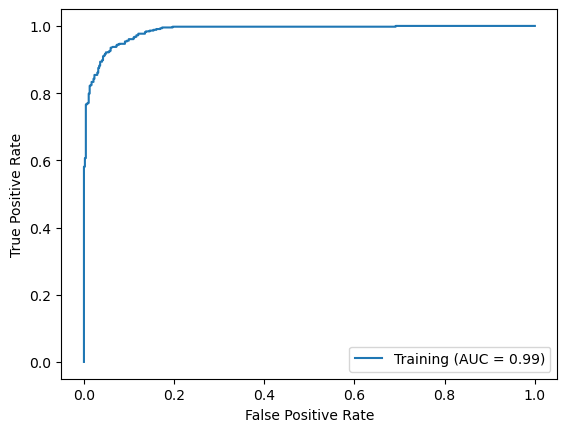

Testing Accuracy: 0.7628865979381443
Testing MCC Score: 0.5208079320988963
Testing F1 Score: 0.7562547798535999
Testing AUC VALUE: 0.8126072041166381
Testing kappa Score: 0.5151054118669854
Testing Precision: 0.7837837837837838
Testing Recall: 0.6590909090909091
Testing Sensitivity: 0.6590909090909091
Testing Specificity: 0.8490566037735849
Testing CCR: 0.7628865979381443
Testing PPV: 0.7837837837837838


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


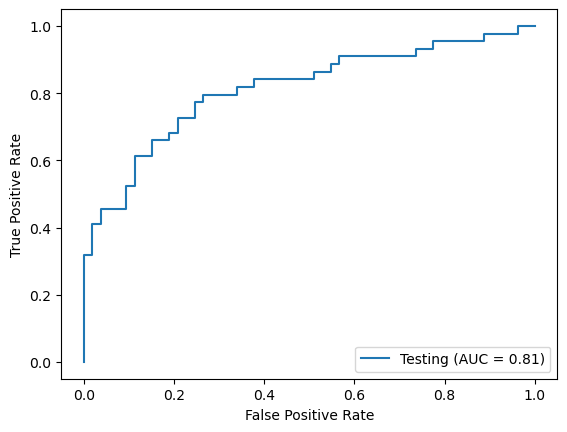

2024-11-04 22:26:48,426:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:26:48,427:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:26:48,428:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #2


C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


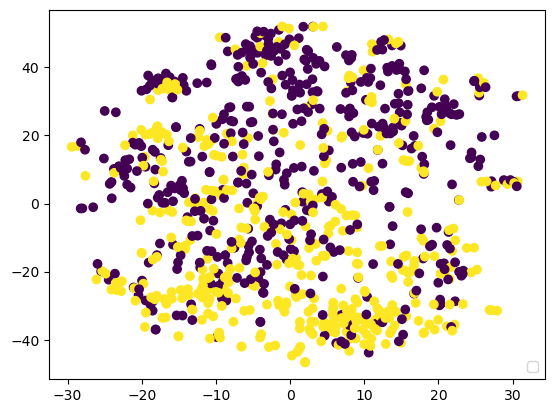

0  
0.0    474
1.0    432
Name: count, dtype: int64
Training Accuracy: 0.9194260485651214
Training MCC Score: 0.8386372626468396
Training F1 Score: 0.9191280136853135
Training AUC VALUE: 0.9804974410064072
Training kappa Score: 0.8382894447297
Training Precision: 0.9284009546539379
Training Recall: 0.9004629629629629
Training Sensitivity: 0.9004629629629629
Training Specificity: 0.9367088607594937
Training CCR: 0.9194260485651214
Training PPV: 0.9284009546539379


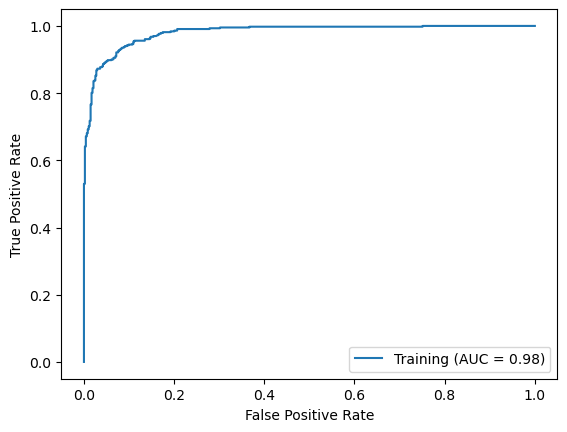

Testing Accuracy: 0.75
Testing MCC Score: 0.4951759739721276
Testing F1 Score: 0.7472575691092584
Testing AUC VALUE: 0.8168706293706294
Testing kappa Score: 0.49473684210526314
Testing Precision: 0.7380952380952381
Testing Recall: 0.7045454545454546
Testing Sensitivity: 0.7045454545454546
Testing Specificity: 0.7884615384615384
Testing CCR: 0.75
Testing PPV: 0.7380952380952381


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


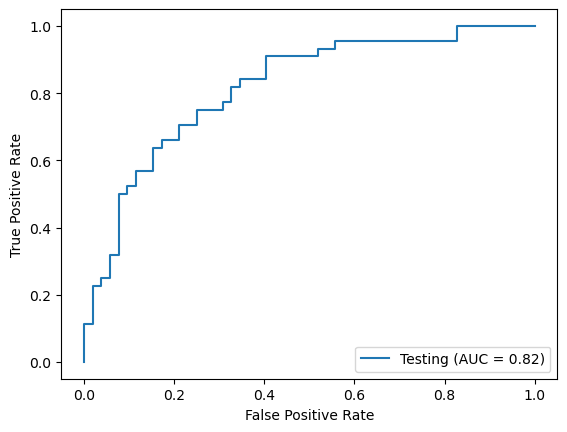

2024-11-04 22:26:50,255:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:26:50,256:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:26:50,257:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #3


C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


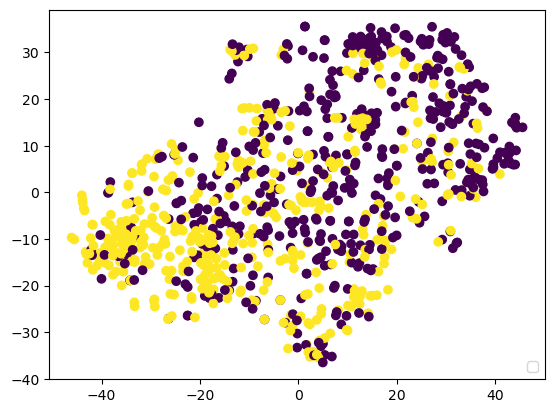

0  
0.0    474
1.0    432
Name: count, dtype: int64
Training Accuracy: 0.9150110375275938
Training MCC Score: 0.8296332519517589
Training F1 Score: 0.9147617098486747
Training AUC VALUE: 0.9813105563369277
Training kappa Score: 0.8295336255809521
Training Precision: 0.9176470588235294
Training Recall: 0.9027777777777778
Training Sensitivity: 0.9027777777777778
Training Specificity: 0.9261603375527426
Training CCR: 0.9150110375275938
Training PPV: 0.9176470588235294


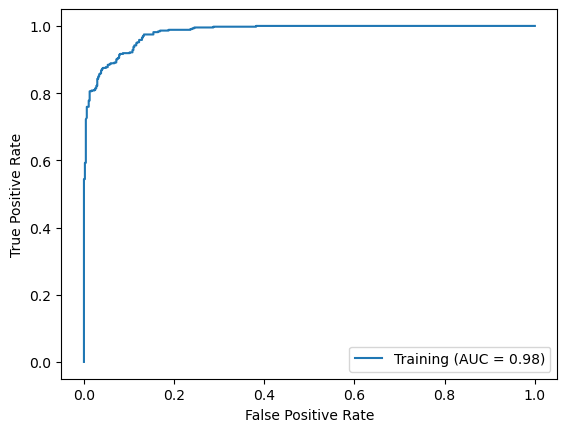

Testing Accuracy: 0.7604166666666666
Testing MCC Score: 0.5159722303596261
Testing F1 Score: 0.7572292468389225
Testing AUC VALUE: 0.7718531468531469
Testing kappa Score: 0.5149384885764499
Testing Precision: 0.7560975609756098
Testing Recall: 0.7045454545454546
Testing Sensitivity: 0.7045454545454546
Testing Specificity: 0.8076923076923077
Testing CCR: 0.7604166666666666
Testing PPV: 0.7560975609756098


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


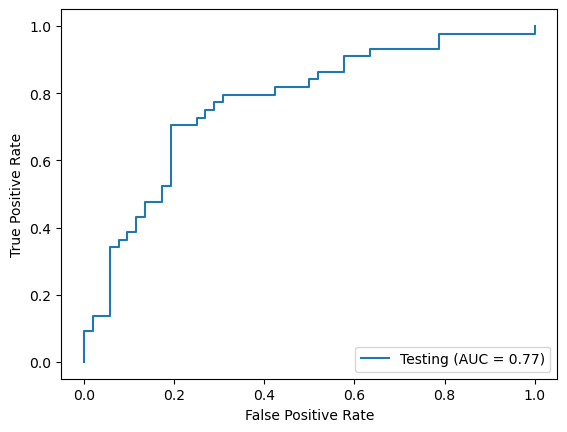

2024-11-04 22:26:52,030:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:26:52,031:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:26:52,031:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #4


C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


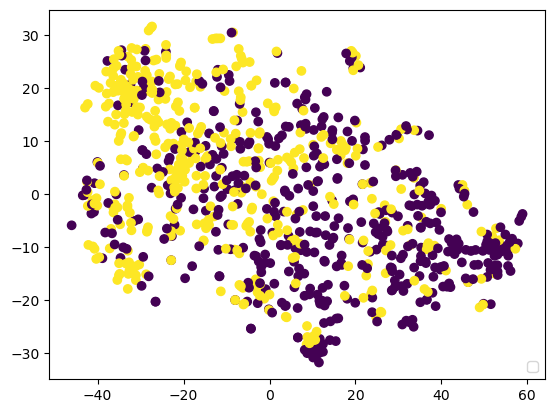

0  
0.0    474
1.0    432
Name: count, dtype: int64
Training Accuracy: 0.9183222958057395
Training MCC Score: 0.8362895553632138
Training F1 Score: 0.9180727720642865
Training AUC VALUE: 0.9806122050320363
Training kappa Score: 0.836158357771261
Training Precision: 0.9221698113207547
Training Recall: 0.9050925925925926
Training Sensitivity: 0.9050925925925926
Training Specificity: 0.930379746835443
Training CCR: 0.9183222958057395
Training PPV: 0.9221698113207547


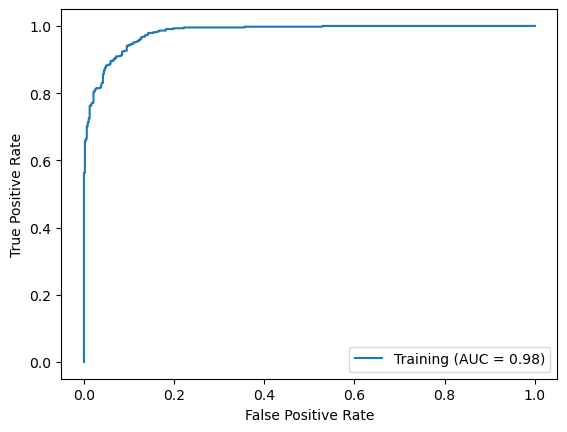

Testing Accuracy: 0.6458333333333334
Testing MCC Score: 0.28069178610689477
Testing F1 Score: 0.6357142857142857
Testing AUC VALUE: 0.7307692307692308
Testing kappa Score: 0.276595744680851
Testing Precision: 0.6388888888888888
Testing Recall: 0.5227272727272727
Testing Sensitivity: 0.5227272727272727
Testing Specificity: 0.75
Testing CCR: 0.6458333333333334
Testing PPV: 0.6388888888888888


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


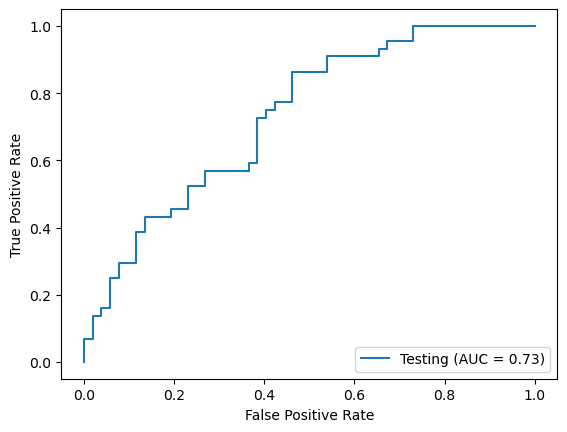

2024-11-04 22:26:53,793:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:26:53,794:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:26:53,795:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #5


C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


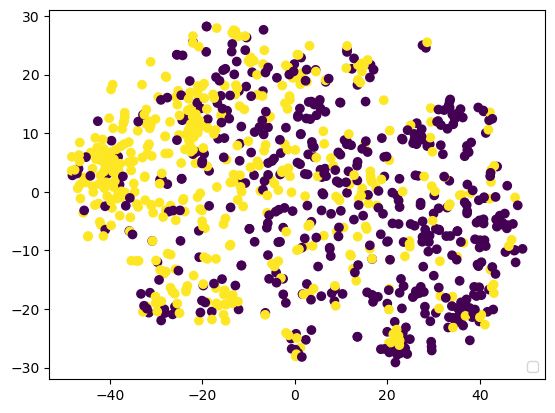

0  
0.0    474
1.0    432
Name: count, dtype: int64
Training Accuracy: 0.9183222958057395
Training MCC Score: 0.8363865641942261
Training F1 Score: 0.9180311032863849
Training AUC VALUE: 0.980280121894046
Training kappa Score: 0.836091063779851
Training Precision: 0.9261904761904762
Training Recall: 0.9004629629629629
Training Sensitivity: 0.9004629629629629
Training Specificity: 0.9345991561181435
Training CCR: 0.9183222958057395
Training PPV: 0.9261904761904762


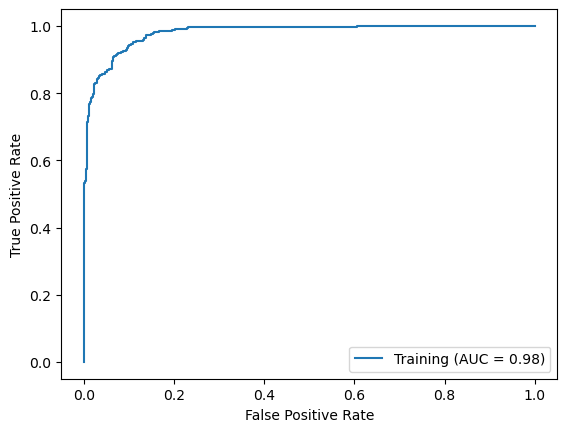

Testing Accuracy: 0.6979166666666666
Testing MCC Score: 0.38910920199617766
Testing F1 Score: 0.6881371121317352
Testing AUC VALUE: 0.7967657342657343
Testing kappa Score: 0.3818827708703374
Testing Precision: 0.7142857142857143
Testing Recall: 0.5681818181818182
Testing Sensitivity: 0.5681818181818182
Testing Specificity: 0.8076923076923077
Testing CCR: 0.6979166666666666
Testing PPV: 0.7142857142857143


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


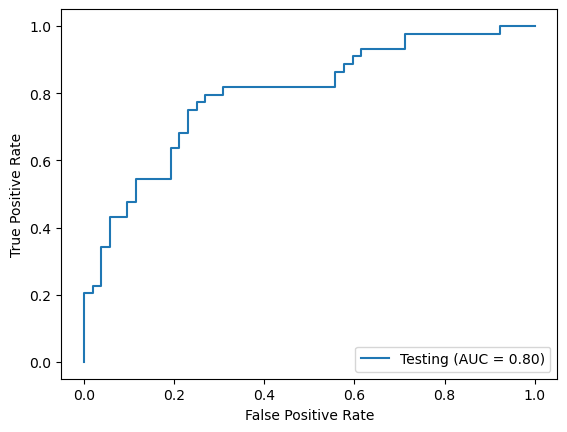

2024-11-04 22:26:55,492:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:26:55,493:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:26:55,494:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #6


C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


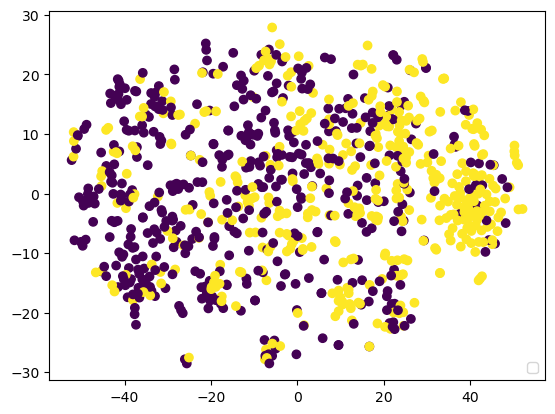

0  
0.0    473
1.0    432
Name: count, dtype: int64
Training Accuracy: 0.9270718232044199
Training MCC Score: 0.8538604895743459
Training F1 Score: 0.9268574031622877
Training AUC VALUE: 0.9821862031164357
Training kappa Score: 0.8537262700076407
Training Precision: 0.9316037735849056
Training Recall: 0.9143518518518519
Training Sensitivity: 0.9143518518518519
Training Specificity: 0.9386892177589852
Training CCR: 0.9270718232044199
Training PPV: 0.9316037735849056


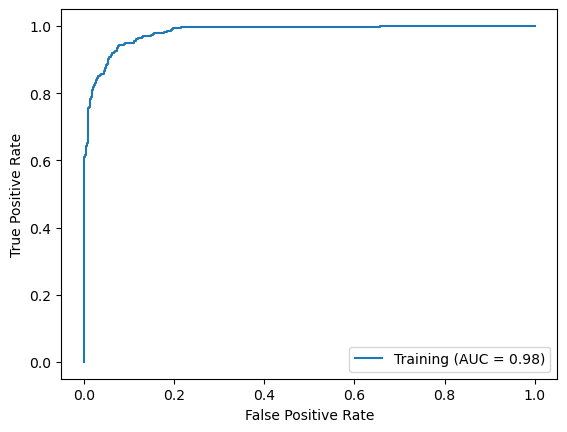

Testing Accuracy: 0.6458333333333334
Testing MCC Score: 0.28099202663396394
Testing F1 Score: 0.6402116402116402
Testing AUC VALUE: 0.735410267661255
Testing kappa Score: 0.2807404142794183
Testing Precision: 0.6097560975609756
Testing Recall: 0.5813953488372093
Testing Sensitivity: 0.5813953488372093
Testing Specificity: 0.6981132075471698
Testing CCR: 0.6458333333333334
Testing PPV: 0.6097560975609756


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


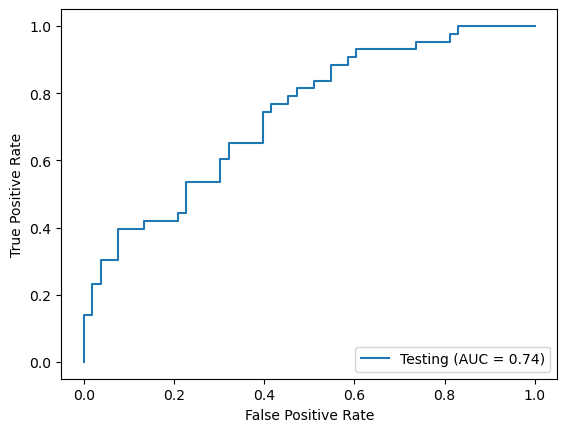

2024-11-04 22:26:57,241:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:26:57,242:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:26:57,243:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #7


C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


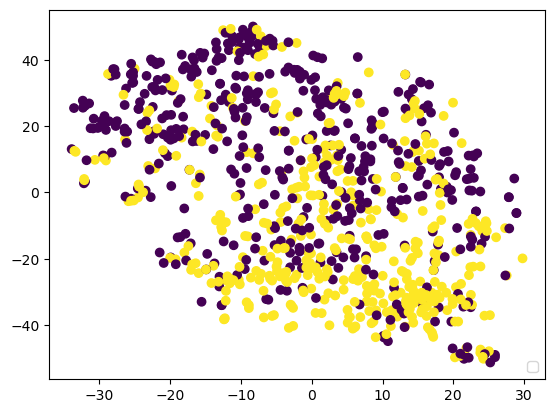

0  
0.0    473
1.0    432
Name: count, dtype: int64
Training Accuracy: 0.9226519337016574
Training MCC Score: 0.8449940212963676
Training F1 Score: 0.9224245185054567
Training AUC VALUE: 0.9808526153002897
Training kappa Score: 0.8448611954626492
Training Precision: 0.9268867924528302
Training Recall: 0.9097222222222222
Training Sensitivity: 0.9097222222222222
Training Specificity: 0.9344608879492601
Training CCR: 0.9226519337016574
Training PPV: 0.9268867924528302


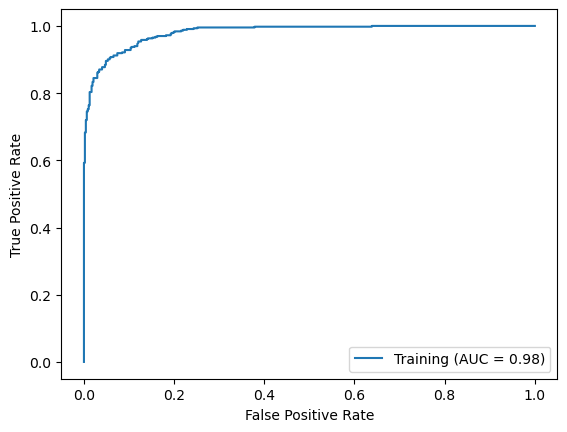

Testing Accuracy: 0.6458333333333334
Testing MCC Score: 0.28099202663396394
Testing F1 Score: 0.6402116402116402
Testing AUC VALUE: 0.7389205792014042
Testing kappa Score: 0.2807404142794183
Testing Precision: 0.6097560975609756
Testing Recall: 0.5813953488372093
Testing Sensitivity: 0.5813953488372093
Testing Specificity: 0.6981132075471698
Testing CCR: 0.6458333333333334
Testing PPV: 0.6097560975609756


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


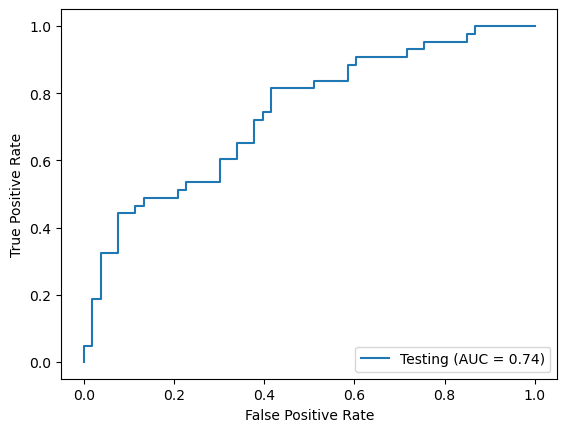

2024-11-04 22:26:58,959:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:26:58,960:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:26:58,961:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #8


C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


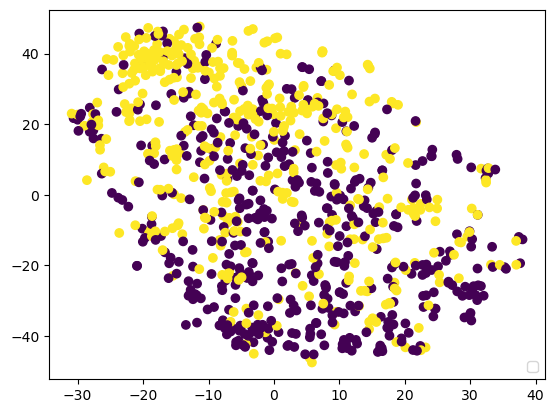

0  
0.0    473
1.0    432
Name: count, dtype: int64
Training Accuracy: 0.9237569060773481
Training MCC Score: 0.8472306983356859
Training F1 Score: 0.9235234683567557
Training AUC VALUE: 0.9817481990447107
Training kappa Score: 0.8470621082872278
Training Precision: 0.9290780141843972
Training Recall: 0.9097222222222222
Training Sensitivity: 0.9097222222222222
Training Specificity: 0.9365750528541226
Training CCR: 0.9237569060773481
Training PPV: 0.9290780141843972


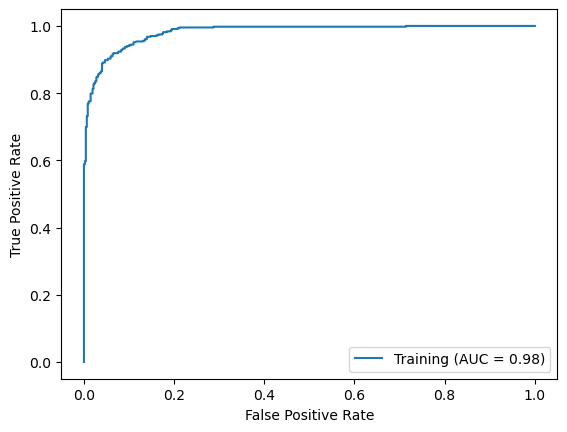

Testing Accuracy: 0.6770833333333334
Testing MCC Score: 0.3485883712005189
Testing F1 Score: 0.6742200328407224
Testing AUC VALUE: 0.7762176393154893
Testing kappa Score: 0.3485113835376533
Testing Precision: 0.6363636363636364
Testing Recall: 0.6511627906976745
Testing Sensitivity: 0.6511627906976745
Testing Specificity: 0.6981132075471698
Testing CCR: 0.6770833333333334
Testing PPV: 0.6363636363636364


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


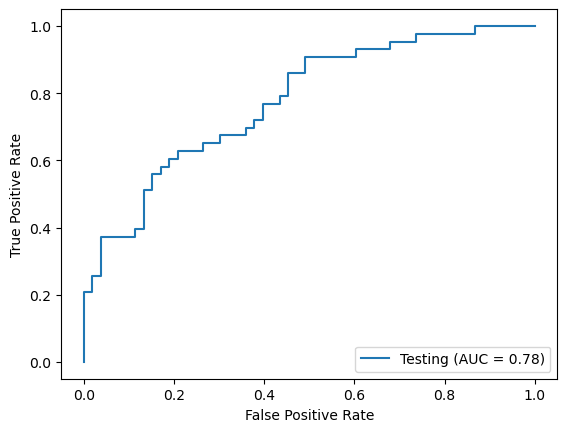

2024-11-04 22:27:00,662:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:27:00,663:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:27:00,664:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #9


C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


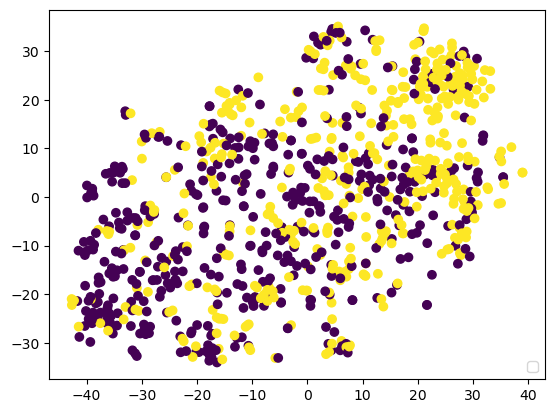

0  
0.0    473
1.0    432
Name: count, dtype: int64
Training Accuracy: 0.9359116022099447
Training MCC Score: 0.8715934261303026
Training F1 Score: 0.9357231724759498
Training AUC VALUE: 0.9852571255187534
Training kappa Score: 0.8714564190976236
Training Precision: 0.9410377358490566
Training Recall: 0.9236111111111112
Training Sensitivity: 0.9236111111111112
Training Specificity: 0.9471458773784355
Training CCR: 0.9359116022099447
Training PPV: 0.9410377358490566


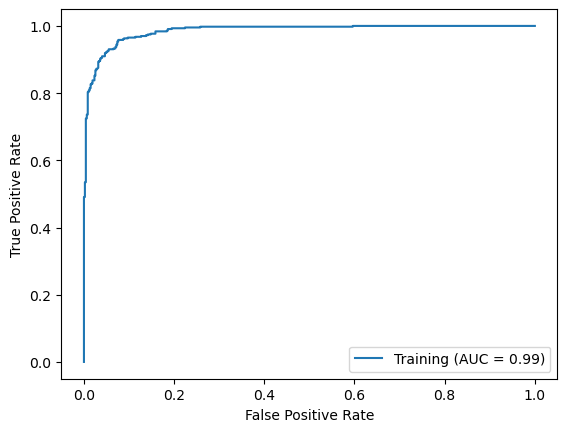

Testing Accuracy: 0.7708333333333334
Testing MCC Score: 0.5391375355073251
Testing F1 Score: 0.7692307692307692
Testing AUC VALUE: 0.7841158402808249
Testing kappa Score: 0.5386631716906947
Testing Precision: 0.7333333333333333
Testing Recall: 0.7674418604651163
Testing Sensitivity: 0.7674418604651163
Testing Specificity: 0.7735849056603774
Testing CCR: 0.7708333333333334
Testing PPV: 0.7333333333333333


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


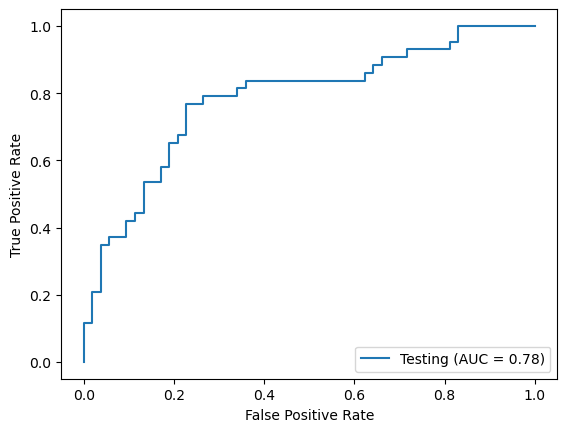

2024-11-04 22:27:02,367:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 22:27:02,368:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 22:27:02,368:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #10


C:\Users\DELL\AppData\Local\Temp\ipykernel_87412\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


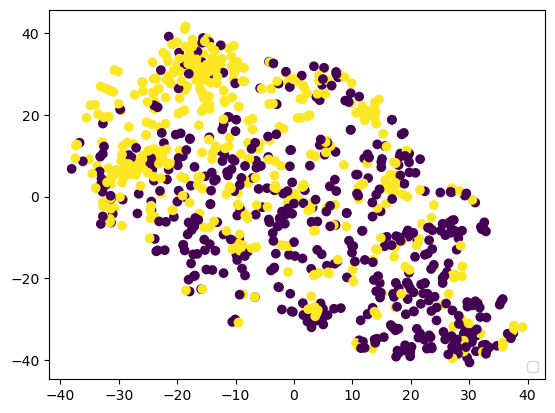

0  
0.0    473
1.0    432
Name: count, dtype: int64
Training Accuracy: 0.918232044198895
Training MCC Score: 0.8362262508355905
Training F1 Score: 0.9179506405167259
Training AUC VALUE: 0.979394233027954
Training kappa Score: 0.8359302268606987
Training Precision: 0.9261904761904762
Training Recall: 0.9004629629629629
Training Sensitivity: 0.9004629629629629
Training Specificity: 0.9344608879492601
Training CCR: 0.918232044198895
Training PPV: 0.9261904761904762


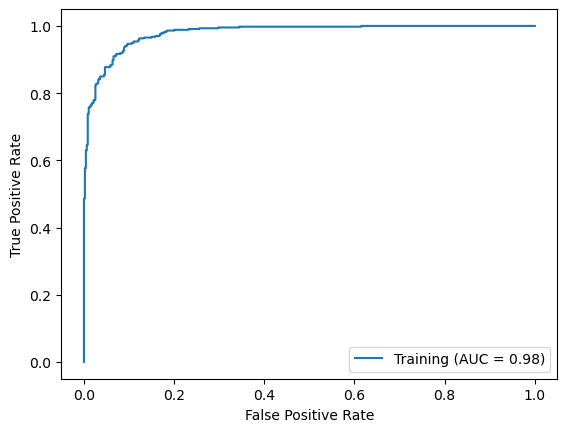

Testing Accuracy: 0.6875
Testing MCC Score: 0.3681439227731461
Testing F1 Score: 0.6840719613865731
Testing AUC VALUE: 0.7661254936375603
Testing kappa Score: 0.3681439227731461
Testing Precision: 0.6511627906976745
Testing Recall: 0.6511627906976745
Testing Sensitivity: 0.6511627906976745
Testing Specificity: 0.7169811320754716
Testing CCR: 0.6875
Testing PPV: 0.6511627906976745


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


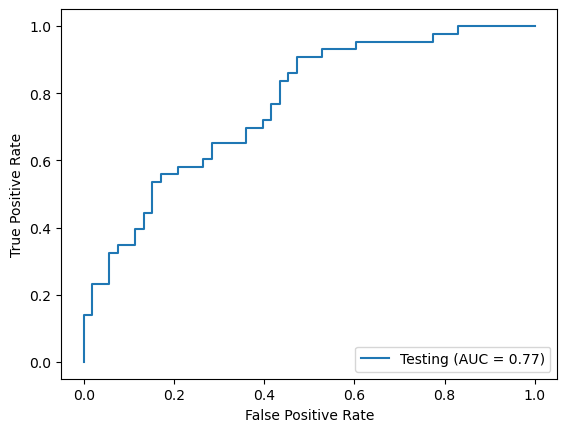

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob)\n    all_labels.extend(Final_Ytrain)\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob)\n    all_labels.extend(Test_y)\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [40]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

Train_Fold_outs_1 = []
Test_Fold_outs_1 = []
models_1 = []

# 用于存储训练和测试集的预测结果和标签

total_metrics = []

# 定义 10 折交叉验证
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 获取特征和标签
X = Data[f_list].values  # 替换 Data 为你的数据集，f_list 为你的特征列表
y = Data['status'].values

Parameters = pd.DataFrame.from_dict(Best_params).iloc[10].to_dict()
print(Parameters)
# 10 折交叉验证
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f'Fold #{fold+1}')
    
    # 获取训练集和测试集
    Train_x, Test_x = X[train_index], X[test_index]
    Train_y, Test_y = y[train_index], y[test_index]
    
    # Upsampling
    Final_Xtrain, Final_Ytrain = Smote(pd.DataFrame(Train_x, columns=f_list), pd.Series(Train_y), 0.5)
    print(Final_Ytrain.value_counts())
    Final_Ytrain = Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype=np.float64)
    Test_x_filtered = pd.DataFrame(Test_x, dtype=np.float64)

    # 使用 KNeighborsClassifier
    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])

    
    # 拟合模型
    rf.fit(Final_Xtrain, Final_Ytrain)
    models_1.append(rf)
    
    # 训练集预测
    y_train_pred = rf.predict(Final_Xtrain)
    y_train_prob = rf.predict_proba(Final_Xtrain)[:, 1]
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred, y_train_prob, Final_Ytrain, 'Training'))

    # 测试集预测
    y_test_pred = rf.predict(Test_x_filtered)
    y_test_prob = rf.predict_proba(Test_x_filtered)[:, 1]
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred, y_test_prob, Test_y, 'Testing'))
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob)
    all_labels.extend(Final_Ytrain)
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob)
    all_labels.extend(Test_y)

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

In [41]:
#Analyse the training metrics sorted by descending Training Accuracy
pd.DataFrame.from_dict(Test_Fold_outs_1).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
8,0.770833,0.539138,0.769231,0.784116,0.538663,0.733333,0.767442,0.767442,0.773585,0.770833,0.733333
0,0.762887,0.520808,0.756255,0.812607,0.515105,0.783784,0.659091,0.659091,0.849057,0.762887,0.783784
2,0.760417,0.515972,0.757229,0.771853,0.514938,0.756098,0.704545,0.704545,0.807692,0.760417,0.756098
1,0.750000,0.495176,0.747258,0.816871,0.494737,0.738095,0.704545,0.704545,0.788462,0.750000,0.738095
4,0.697917,0.389109,0.688137,0.796766,0.381883,0.714286,0.568182,0.568182,0.807692,0.697917,0.714286
9,0.687500,0.368144,0.684072,0.766125,0.368144,0.651163,0.651163,0.651163,0.716981,0.687500,0.651163
7,0.677083,0.348588,0.674220,0.776218,0.348511,0.636364,0.651163,0.651163,0.698113,0.677083,0.636364
5,0.645833,0.280992,0.640212,0.735410,0.280740,0.609756,0.581395,0.581395,0.698113,0.645833,0.609756
6,0.645833,0.280992,0.640212,0.738921,0.280740,0.609756,0.581395,0.581395,0.698113,0.645833,0.609756
3,0.645833,0.280692,0.635714,0.730769,0.276596,0.638889,0.522727,0.522727,0.750000,0.645833,0.638889


<Axes: >

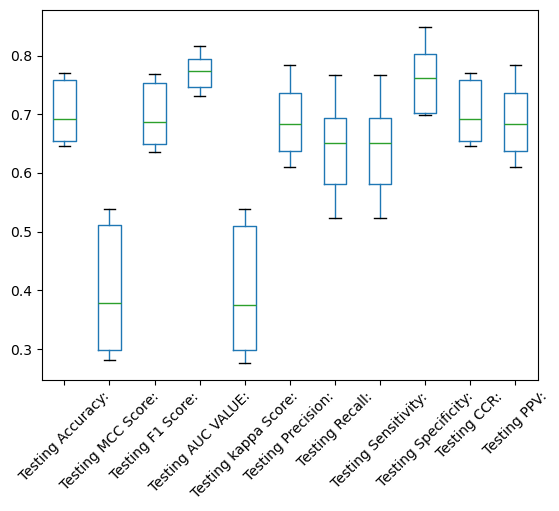

In [42]:
#To visualize the stability of the tuned model with each fold
(pd.DataFrame(Test_Fold_outs_1)).boxplot(grid=False,rot=45)

In [43]:
pd.DataFrame(Test_Fold_outs_1)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
0,0.762887,0.520808,0.756255,0.812607,0.515105,0.783784,0.659091,0.659091,0.849057,0.762887,0.783784
1,0.750000,0.495176,0.747258,0.816871,0.494737,0.738095,0.704545,0.704545,0.788462,0.750000,0.738095
2,0.760417,0.515972,0.757229,0.771853,0.514938,0.756098,0.704545,0.704545,0.807692,0.760417,0.756098
3,0.645833,0.280692,0.635714,0.730769,0.276596,0.638889,0.522727,0.522727,0.750000,0.645833,0.638889
4,0.697917,0.389109,0.688137,0.796766,0.381883,0.714286,0.568182,0.568182,0.807692,0.697917,0.714286
5,0.645833,0.280992,0.640212,0.735410,0.280740,0.609756,0.581395,0.581395,0.698113,0.645833,0.609756
6,0.645833,0.280992,0.640212,0.738921,0.280740,0.609756,0.581395,0.581395,0.698113,0.645833,0.609756
7,0.677083,0.348588,0.674220,0.776218,0.348511,0.636364,0.651163,0.651163,0.698113,0.677083,0.636364
8,0.770833,0.539138,0.769231,0.784116,0.538663,0.733333,0.767442,0.767442,0.773585,0.770833,0.733333
9,0.687500,0.368144,0.684072,0.766125,0.368144,0.651163,0.651163,0.651163,0.716981,0.687500,0.651163


In [44]:
TRAIN = Data.drop(['smiles','status'],axis=1)
TRAIN

,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,A1_9,...,E5_118,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127
0,-0.103999,0.097738,0.100539,-0.103800,0.061276,-0.105713,-0.006544,0.027760,-0.060200,0.042040,...,-0.086917,-0.001032,-0.138497,0.067248,0.075819,-0.061462,0.121833,0.110668,0.057597,0.113798
1,0.093736,0.085746,0.093669,-0.093733,-0.093736,-0.093322,0.093736,-0.093720,-0.093735,0.059581,...,-0.026415,0.119321,-0.005243,-0.015744,-0.010452,0.022232,0.016749,0.094246,-0.123218,-0.099457
2,-0.100092,-0.099088,-0.084504,-0.094028,0.085655,0.100332,0.010789,-0.028890,0.082395,-0.019364,...,0.014489,-0.014538,-0.108730,0.071725,0.064377,-0.096417,-0.119392,0.056950,0.105985,0.040311
3,-0.098335,-0.081193,0.049595,-0.061777,-0.066672,-0.022043,0.087456,-0.098040,0.047128,0.098288,...,-0.105842,-0.059380,-0.026610,0.045300,-0.068234,0.028847,-0.068210,0.011231,0.146784,-0.091332
4,-0.096464,0.053822,-0.087383,0.095549,-0.091416,0.096470,0.096480,-0.096477,-0.077987,-0.029744,...,-0.012364,-0.118487,-0.006075,0.104476,0.081948,-0.120817,-0.001020,-0.131218,0.095820,-0.004740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,0.086594,0.097406,0.096966,-0.097145,0.097028,-0.091569,-0.071954,0.097492,0.096533,0.089626,...,-0.159002,-0.141212,-0.046718,-0.069887,0.049093,-0.093039,-0.117753,0.079444,0.002861,0.134517
957,-0.084900,0.094649,0.092521,0.063585,-0.094093,0.094662,0.094667,-0.094671,-0.056504,0.094650,...,-0.028190,-0.035826,-0.032917,-0.005921,0.106586,-0.022346,-0.005595,0.090953,0.174594,0.115123
958,-0.096963,0.096944,0.055419,0.031063,-0.096089,0.097074,0.097105,-0.097106,-0.046417,0.096653,...,0.000893,-0.033102,0.000861,-0.028923,0.096171,0.038505,-0.103363,0.118180,0.117282,0.098737
959,-0.097246,0.073239,0.031616,0.070694,-0.013785,0.097282,0.097095,-0.097314,-0.061902,0.095286,...,0.000787,-0.037974,-0.103768,0.069785,0.098978,-0.064144,-0.107851,0.066537,0.132164,0.064070


In [45]:
TRAIN = TRAIN[f_list] #Use features of the selected (hyperparameter tuned) model here
TRAIN

,A1_42,A4_125,B2_52,B3_1,B3_56,C1_73,C1_95,D1_64,D1_78,D1_97,...,E4_35,E4_37,E4_70,E4_74,E4_79,E4_89,E4_116,E4_117,E4_122,E4_125
0,-0.093255,0.098075,0.011723,-0.141467,-0.085162,0.078998,0.052873,-0.116357,0.114127,0.095775,...,0.109693,0.047163,-0.099689,0.041719,0.030193,-0.117199,0.096472,-0.101943,-0.088412,0.117076
1,-0.093736,-0.008180,0.132104,-0.103231,-0.030580,-0.112107,0.112063,-0.094787,0.116802,0.098403,...,0.092517,0.104350,-0.103559,-0.104341,0.104087,-0.101690,-0.104425,0.104410,0.104501,-0.104382
2,-0.079024,0.101227,0.002043,-0.025083,0.078537,-0.060159,0.087306,-0.013367,0.007587,0.134467,...,-0.095563,-0.093502,0.117030,-0.036332,-0.106362,-0.106826,-0.089854,-0.109663,-0.067218,0.111537
3,-0.098462,0.062638,0.145905,-0.040591,-0.113748,-0.125457,0.123037,-0.129018,0.089010,0.133396,...,0.015803,0.124122,-0.063900,0.086929,-0.097302,-0.133906,-0.026821,0.062109,0.134571,-0.046167
4,-0.096071,-0.088404,0.033850,-0.103097,0.095654,-0.111784,0.028632,-0.022850,0.061155,0.056123,...,0.078909,0.118211,-0.117618,-0.131995,0.122496,-0.136267,-0.129429,0.070241,0.129967,-0.115071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,0.046133,0.094864,-0.116918,-0.095246,-0.118638,-0.066231,0.111348,-0.111421,0.112462,0.104668,...,-0.107475,0.048395,-0.030832,-0.060154,0.081244,-0.104876,-0.077589,0.089040,0.040069,0.096061
957,-0.094661,0.097846,0.038828,-0.110238,0.097776,-0.037575,-0.004040,-0.017981,-0.085095,0.102468,...,0.077826,-0.005024,0.053300,0.005661,0.011867,-0.107319,-0.005118,-0.146000,-0.113982,0.145774
958,-0.097080,0.097217,0.086251,0.015070,0.114789,0.016819,-0.025570,-0.085581,-0.041148,0.101713,...,0.102224,0.027850,0.002027,0.032835,0.012784,-0.129188,-0.023907,-0.141674,-0.120126,0.132213
959,-0.097005,0.095769,0.076788,-0.004494,0.118227,0.031080,0.054976,-0.066402,-0.004433,0.099084,...,0.080453,0.049483,0.038522,0.042805,-0.020827,-0.125696,-0.083514,-0.136084,-0.130289,0.125629


In [46]:
Y = Data['status']

In [48]:
#Fitting the model on whole data
fitted = models_1[8].fit(TRAIN,Y)
fitted

RandomForestClassifier(bootstrap=False, max_depth=90.0, max_features='log2',
                       min_samples_leaf=12, min_samples_split=18,
                       n_estimators=56)

In [49]:
#Save the final model
joblib.dump(fitted, 'AID_1199_RF.pkl')

['AID_1199_RF.pkl']

In [18]:
import joblib
import pandas as pd

class model_AID_1199:
    def __init__(self, test):        
        self.test = test

    def extract_feature(self, data):        
        # 读取特征文件
        F_names = pd.read_csv('AID_1199_features.csv')
        features = F_names.iloc[:, 0].tolist()
        return data[features]

    def get_labels(self, pred_test):
        # 根据概率预测类别
        test_pred = []
        for i in range(pred_test.shape[0]):
            if pred_test[i][0] > pred_test[i][1]:  # 类别 0 概率更大
                test_pred.append(0)
            else:
                test_pred.append(1)  # 类别 1 概率更大
        return test_pred

    def test_model(self):
        # 提取特征并加载本地的 KNN 模型进行预测
        test = self.test
        test_filtered = self.extract_feature(test.drop(['smiles'], axis=1))
        
        # 本地加载 KNN 模型
        model = joblib.load('AID_1199_RF.pkl')
        
        # 使用模型进行预测
        probs = model.predict_proba(test_filtered)
        
        # 获取预测类别
        preds = self.get_labels(probs)
        
        return probs, preds


def AID_1199(smi_list):
    Feature_data = pd.DataFrame()
    Feature_data['smiles'] = smi_list

    Sig_Carcin = Feature_Signaturizer(smi_list)
    
    # 保留删除前的索引
    original_index = Sig_Carcin.index
    
    # 删除缺失值的行
    Sig_Carcin_clean = Sig_Carcin.dropna()

    # 使用清理过的数据进行模型测试
    m4 = model_AID_1199(Sig_Carcin_clean)  # 假设这里的模型函数改为 model_apoptosis
    probs, preds = m4.test_model()

    # 创建一个与原始索引匹配的结果数组
    Feature_data['AID_1199_0'] = None
    Feature_data['AID_1199_1'] = None
    Feature_data['AID_1199_preds'] = None

    # 填充有效的预测结果
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1199_0'] = probs[:, 0]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1199_1'] = probs[:, 1]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1199_preds'] = preds

    return Feature_data


In [19]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'MKETn_Training_Data.csv') ### features in columns,molecules in rows
data

,SMILES,Name,CID,InChI,IUPAC,Status,Source
0,[As],Arsenic,5359596.0,1S/As,arsenic,1,CCRIS
1,[Be],Beryllium,5460467.0,1S/Be,beryllium,1,CCRIS
2,[Be]=O,Beryllium oxide,14775.0,1S/Be.O,oxoberyllium,1,CCRIS
3,[Be+2].[OH-].[OH-],Dihydroxyberyllium,25879.0,1S/Be.2H2O/h;2*1H2/q+2;;/p-2,beryllium;dihydroxide,1,CCRIS
4,[C-]#[Si+],Silicon carbide,9863.0,1S/CSi/c1-2,methanidylidynesilanylium,1,CCRIS
...,...,...,...,...,...,...,...
461,P#[Ga],Gallium phosphide,82901.0,1S/Ga.P,gallanylidynephosphane,0,CCRIS
462,S=[Cd],Cadmium sulfide,14783.0,1S/Cd.S,sulfanylidenecadmium,1,CCRIS
463,S=[Ni],Nickel sulfide,28094.0,1S/Ni.S,sulfanylidenenickel,1,CCRIS
464,S=P(N1CC1)(N1CC1)N1CCOCC1,Morzid,62432.0,"1S/C8H16N3OPS/c14-13(9-1-2-9,10-3-4-10)11-5-7-...",bis(aziridin-1-yl)-morpholin-4-yl-sulfanyliden...,1,CCRIS
